<div style="border-left: 4px solid #FFB347; border-radius: 6px; background-color: white; box-shadow: 0 3px 10px rgba(0,0,0,0.12); overflow:hidden;">
  <div style="background-color:#FFF4E0; padding:12px 16px;">
    <h2 style="margin:0; font-weight:700;">Equity Risk Modelling — Regime-Aware PCA, Heavy Tails, EWMA Benchmarks, and Kalman Factor Premia</h2>
    <div style="margin-top:6px; font-size:13px; line-height:1.35;">
      <b>Goal:</b> build and stress-test out-of-sample covariance / density forecasts, with an optional expected-return layer for a broad US large-cap equity panel, comparing low-rank PCA, VIX/HMM regime mixtures, eigenstructure regimes, and shrinkage EWMA covariance models under Gaussian and Student-t scoring.
    </div>
  </div>
  <div style="padding:12px 16px; font-size:14px; line-height:1.45;">
    <ul>
      <li><b>Part A:</b> VIX-driven regime-aware PCA and calm/stress HMM covariance mixtures, evaluated with static and walk-forward OOS Gaussian NLL.</li>
      <li><b>Part B:</b> heavy-tailed likelihoods, full EWMA covariance benchmarks, eigenstructure-defined regimes, Random-Matrix diagnostics, and confound controls.</li>
      <li><b>Finalisation:</b> extended lambda validation and a VaR/ES capstone are included at the end of the notebook.</li>
      <li><b>Important reading rule:</b> the notebook distinguishes validation-selected live candidates from best realised static OOS diagnostics; test-set winners are not used for selection.</li>
      <li><b>Sample note:</b> data are requested from 2010 onward, but the effective common return sample starts on <b>2012-05-21</b> because the analysis uses the intersection of available histories across the 24-name panel.</li>
    </ul>
  </div>
</div>

<h3 style="font-weight:700;">0) Setup</h3>


In [1]:
# --- standard libs
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: sklearn for Ledoit–Wolf
try:
    from sklearn.covariance import LedoitWolf
    _HAS_SKLEARN = True
except Exception:
    _HAS_SKLEARN = False

# Optional: yfinance for data (the notebook runs also with CSV inputs)
try:
    import yfinance as yf
    _HAS_YFINANCE = True
except Exception:
    _HAS_YFINANCE = False

print("sklearn:", _HAS_SKLEARN, "| yfinance:", _HAS_YFINANCE)


sklearn: True | yfinance: True


<h3 style="font-weight:700;">1) Configuration</h3>
Reproducible settings for the broad US large-cap equity experiment. The current run uses a 24-name panel, a VIX-based state variable, and a 2-state HMM (calm/stress).

In [2]:

CONFIG = dict(
    # Universe
    tickers=[
        "AAPL","MSFT","NVDA","ORCL","GOOGL","META","AMZN","HD","WMT","PG","KO",
        "JPM","BRK-B","V","LLY","JNJ","UNH","XOM","CVX","CAT","RTX","LIN","NEE","AMT"
    ],
    # Implied-volatility proxy
    iv_ticker="^VIX",

    # Data range
    start="2010-01-01",
    end=None,  # None = today

    # Train / test split
    train_start="2010-01-01",
    train_end="2021-12-31",
    test_start="2022-01-01",
    test_end="2026-03-31",

    # Returns
    returns="simple",   # "simple" or "log"

    # PCA factors
    k=3,

    # State variable z_t (log(IV) -> smoothing -> EWMA z-score)
    smooth_window=5,
    ewma_lambda=0.94,

    # --- Piecewise PCA baseline (thresholds selected from HMM information)
    do_piecewise_pca=True,
    regime_labels=("low","mid","high"),
    min_obs_regime=80,
    piecewise_threshold_grid_size=41,   # grid used to search HMM-informed z-thresholds

    # --- HMM (2-state) on z_t
    hmm_n_states=2,
    hmm_max_iter=200,
    hmm_tol=1e-6,
    hmm_var_floor=1e-6,
    hmm_seed=7,

    # --- Covariance estimation
    shrink="lw",        # None or "lw" (Ledoit–Wolf)
    min_obs_state=120,  # minimum observations per calm/stress state on train; otherwise fallback to global

    # --- Regime-aware scaling on volatility only (correlation fixed)
    do_volmix_corrfixed=True,

    # --- z feature engineering (IV -> z_t)
    z_mode="level",           # "level" (default), "level+delta", or "level+accel"
    z_w_d1=0.0,               # weight on the first-difference term
    z_w_d2=0.0,               # weight on the second-difference term
    z_use_abs_d1=True,        # use |ΔlogIV| instead of ΔlogIV

    # --- p_t smoothing / calibration (objective choice via validation)
    do_model_selection=True,
    val_years=1,
    p_smoothing_method="auto",  # "auto" or one of: "none","shrink_to_mean","temperature","ema"
    p_smoothing_alpha_grid=[0.0, 0.25, 0.50, 0.75, 0.90, 1.0],
    p_smoothing_T_grid=[0.75, 1.0, 1.25, 1.5, 2.0, 3.0],
    p_smoothing_gamma_grid=[0.0, 0.25, 0.50, 0.75, 0.90],

    # Optional grids for validation-time model selection
    eta_shrink_to_global_grid=[0.0, 0.25, 0.50, 0.75, 0.90],
    cs_estimation_grid=["hard", "weighted"],
    model_family_grid=["mixture", "volmix_corrfixed"],
    shrink_mu_to_global=False,

    # --- Mixture forecast + NLL numerical stabilization
    ridge_mult=1e-3,

    # --- Bootstrap
    do_bootstrap=True,
    bootstrap_B=300,
    bootstrap_block=20,
    bootstrap_seed=7,

    # --- Rolling recalibration (walk-forward)
    do_rolling_recalibration=True,
    rolling_window_years=5,
    rolling_refit_freq="MS",
    hmm_max_iter_rolling=80,
    rolling_min_obs=500,
)


<h3 style="font-weight:700;">2) Data loading</h3>
The notebook supports either:
- download via <code>yfinance</code>
- reading prices from CSV files for fixed, fully reproducible inputs

The current executed run requests data from 2010 onward, but the effective common-sample coverage is determined by the intersection of available histories across all selected tickers plus the IV proxy.

In [3]:

def _to_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    return df

def fetch_prices_yf(tickers, start, end=None, auto_adjust=True) -> pd.DataFrame:
    if not _HAS_YFINANCE:
        raise ImportError("yfinance not available. Provide prices via CSV instead.")
    data = yf.download(tickers=tickers, start=start, end=end, auto_adjust=auto_adjust, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        if ("Close" in data.columns.get_level_values(0)):
            px = data["Close"].copy()
        else:
            px = data.xs(data.columns.levels[0][0], axis=1, level=0).copy()
    else:
        px = data.copy()
    px = _to_datetime_index(px).dropna(how="all")
    return px

def read_prices_csv(path: str, date_col="Date") -> pd.DataFrame:
    df = pd.read_csv(path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).sort_index()
    return df

def compute_returns(prices: pd.DataFrame, kind="simple") -> pd.DataFrame:
    prices = prices.dropna(how="all").copy()
    if kind == "simple":
        rets = prices.pct_change()
    elif kind == "log":
        rets = np.log(prices).diff()
    else:
        raise ValueError("kind must be 'simple' or 'log'")
    return rets.dropna(how="all")

def slice_period(x: pd.DataFrame | pd.Series, start: str, end: str):
    xx = x.copy()
    xx = xx.loc[pd.to_datetime(start):pd.to_datetime(end)]
    return xx

# --- Load prices (edit this block if you prefer CSV)
tickers = CONFIG["tickers"]
iv_ticker = CONFIG["iv_ticker"]

px_assets = fetch_prices_yf(tickers, CONFIG["start"], CONFIG["end"])
px_iv = fetch_prices_yf([iv_ticker], CONFIG["start"], CONFIG["end"]).iloc[:, 0].rename("IV")

rets_assets = compute_returns(px_assets, kind=CONFIG["returns"])
iv = px_iv.reindex(rets_assets.index).dropna()

# Effective common sample after requiring all assets to be present
rets_assets_common = rets_assets.dropna()

# Train / test split
ret_train = slice_period(rets_assets, CONFIG["train_start"], CONFIG["train_end"]).dropna()
ret_test  = slice_period(rets_assets, CONFIG["test_start"],  CONFIG["test_end"]).dropna()
iv_train  = iv.reindex(ret_train.index).dropna()
iv_test   = iv.reindex(ret_test.index).dropna()

print("Requested data start:", pd.to_datetime(CONFIG["start"]).date())
print("Effective common-sample returns coverage:", rets_assets_common.index.min().date(), "->", rets_assets_common.index.max().date())
print("ret_train:", ret_train.shape, "| ret_test:", ret_test.shape, "| iv_train:", iv_train.shape, "| iv_test:", iv_test.shape)

ret_train.head()


Requested data start: 2010-01-01
Effective common-sample returns coverage: 2012-05-21 -> 2026-06-18
ret_train: (2421, 24) | ret_test: (1064, 24) | iv_train: (2421,) | iv_test: (1064,)


Ticker,AAPL,AMT,AMZN,BRK-B,CAT,CVX,GOOGL,HD,JNJ,JPM,...,MSFT,NEE,NVDA,ORCL,PG,RTX,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2012-05-21,0.058261,0.016920,0.019921,0.011279,0.037212,0.012493,0.022835,0.011902,0.001894,-0.029263,...,0.016399,0.003077,0.017384,0.025381,-0.002047,0.018237,0.028894,0.031783,0.009771,0.006997
2012-05-22,-0.007679,-0.006716,-0.012746,-0.001880,-0.005327,-0.003712,-0.021674,0.013652,0.000788,0.046140,...,0.000336,0.006288,-0.012205,0.003808,-0.003786,0.003256,0.003061,0.018671,0.010946,-0.001097
2012-05-23,0.024400,0.001690,0.009056,0.001255,0.010712,-0.003222,0.014414,0.009946,-0.003936,0.007351,...,-0.021842,-0.010212,0.024711,0.012139,-0.012035,0.001623,-0.006461,0.006588,0.013338,0.001098
2012-05-24,-0.009184,0.010279,-0.009389,0.000627,-0.011355,0.010707,-0.009517,0.019902,0.007022,-0.008465,...,-0.001374,0.001386,-0.026527,-0.020989,0.002885,-0.007561,0.015535,0.005035,0.007587,0.006948
2012-05-25,-0.005360,-0.001518,-0.010918,-0.006892,-0.016188,-0.011993,-0.020094,-0.005431,-0.009351,-0.013836,...,-0.000344,0.004613,0.023948,0.000765,-0.001279,-0.006531,-0.001779,-0.003340,0.003688,-0.006416


<h3 style="font-weight:700;">3) Core functions</h3>
Reusable functions for the state variable, shrinkage moments, ARPM-style PCA, evaluation metrics, and the 2-state Gaussian HMM with filtered probabilities (no look-ahead).


In [4]:

# ----------------------------
# 3.1 State variable z_t
# ----------------------------
def ewma_stats(x: pd.Series, lam: float = 0.94) -> pd.DataFrame:
    """EWMA mean/std computed sequentially (past-looking)."""
    x = x.dropna().astype(float)
    m = np.zeros(len(x))
    v = np.zeros(len(x))
    m[0] = x.iloc[0]
    v[0] = 0.0
    for t in range(1, len(x)):
        m[t] = lam * m[t-1] + (1 - lam) * x.iloc[t]
        innov = x.iloc[t] - m[t-1]
        v[t] = lam * v[t-1] + (1 - lam) * innov**2
    s = np.sqrt(np.maximum(v, 1e-12))
    return pd.DataFrame({"ewma_mean": m, "ewma_std": s}, index=x.index)

def build_state_z(
    iv_level: pd.Series,
    smooth_window: int = 5,
    lam: float = 0.94,
    mode: str = "level",
    w_d1: float = 0.0,
    w_d2: float = 0.0,
    use_abs_d1: bool = True,
) -> pd.Series:
    """
    Build a 1D state variable z_t from an implied-volatility level series (past-looking).

    Default (mode="level"):
        z_t = zscore_EWMA( smooth( log(IV_t) ) )

    Extensions:
      - mode="level+delta": adds a term based on ΔlogIV (or |ΔlogIV|), weight w_d1
      - mode="level+accel": adds ΔlogIV and Δ²logIV (acceleration), weights w_d1, w_d2

    Notes:
      • All operations are past-looking (rolling mean + EWMA stats).
      • The combined signal is finally EWMA-zscored to be roughly standardized.
    """
    iv_level = iv_level.dropna().astype(float)
    x = np.log(iv_level)

    # 1) base level (smoothed)
    x_smooth = x.rolling(window=smooth_window, min_periods=smooth_window).mean()

    # 2) optional delta / acceleration (also smoothed)
    if mode in ("level+delta", "level+accel"):
        d1 = x.diff()
        if use_abs_d1:
            d1 = d1.abs()
        d1_smooth = d1.rolling(window=smooth_window, min_periods=smooth_window).mean()
    else:
        d1_smooth = None

    if mode == "level+accel":
        d2 = x.diff().diff()
        d2_smooth = d2.rolling(window=smooth_window, min_periods=smooth_window).mean()
    else:
        d2_smooth = None

    # 3) combine (still in original scale)
    f = x_smooth.copy()
    if d1_smooth is not None and w_d1 != 0:
        f = f + w_d1 * d1_smooth
    if d2_smooth is not None and w_d2 != 0:
        f = f + w_d2 * d2_smooth

    # 4) EWMA z-score (past-looking)
    f = f.dropna()
    stats = ewma_stats(f, lam=lam)
    z = (f.loc[stats.index] - stats["ewma_mean"]) / stats["ewma_std"]
    z.name = "state_z"
    return z

# ----------------------------
# 3.2 Regimes
# ----------------------------

def fit_regime_thresholds_from_hmm(
    z_train: pd.Series,
    p_stress_train: pd.Series,
    labels=("low", "mid", "high"),
    min_obs: int = 80,
    grid_size: int = 41,
) -> tuple[tuple[float, float], pd.DataFrame]:
    """
    Select two z-thresholds for the 3-bucket piecewise PCA baseline using HMM information.

    Criterion:
      - candidate thresholds are searched on an empirical z-grid;
      - the chosen pair maximizes between-bucket variation in the HMM filtered stress probability;
      - average stress probability must be monotone across buckets:
            E[p|low] < E[p|mid] < E[p|high]
      - each bucket must contain at least `min_obs` observations.

    This keeps the piecewise baseline data-driven instead of using hard-coded z-quantiles.
    """
    df = pd.DataFrame({
        "z": pd.Series(z_train).astype(float),
        "p": pd.Series(p_stress_train).astype(float),
    }).dropna().sort_values("z")

    if len(df) < 3 * max(5, int(min_obs)):
        raise ValueError("Not enough observations to select piecewise thresholds from HMM information.")

    q_min = max(0.05, min_obs / len(df))
    q_max = min(0.95, 1.0 - min_obs / len(df))
    if q_min >= q_max:
        q_min, q_max = 0.10, 0.90

    q_grid = np.linspace(q_min, q_max, int(grid_size))
    cand = np.unique(df["z"].quantile(q_grid).values)
    overall_mean = float(df["p"].mean())

    rows = []
    best = None

    for i in range(len(cand)):
        for j in range(i + 1, len(cand)):
            t1, t2 = float(cand[i]), float(cand[j])
            reg = pd.cut(
                df["z"],
                bins=[-np.inf, t1, t2, np.inf],
                labels=list(labels),
                include_lowest=True,
            )
            stats = df.groupby(reg, observed=False)["p"].agg(["mean", "size"])
            if len(stats) != 3 or stats["size"].min() < min_obs:
                continue

            means = stats["mean"].values.astype(float)
            if not (means[0] < means[1] < means[2]):
                continue

            score = float(((stats["mean"] - overall_mean) ** 2 * stats["size"]).sum())

            row = {
                "t_low": t1,
                "t_high": t2,
                "score": score,
                f"mean_p_{labels[0]}": means[0],
                f"mean_p_{labels[1]}": means[1],
                f"mean_p_{labels[2]}": means[2],
                f"n_{labels[0]}": int(stats.loc[labels[0], "size"]),
                f"n_{labels[1]}": int(stats.loc[labels[1], "size"]),
                f"n_{labels[2]}": int(stats.loc[labels[2], "size"]),
            }
            rows.append(row)

            if (best is None) or (score > best["score"]):
                best = row

    if best is None:
        raise ValueError("No valid HMM-informed threshold pair found. Consider lowering min_obs_regime or increasing the sample.")

    ranking = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    return (best["t_low"], best["t_high"]), ranking

def assign_regime(z: pd.Series, thr: tuple[float, float], labels=("low", "mid", "high")) -> pd.Series:
    t_low, t_high = thr
    z = z.dropna().astype(float)

    def lab(v):
        if v <= t_low:
            return labels[0]
        elif v <= t_high:
            return labels[1]
        else:
            return labels[2]

    reg = z.apply(lab)
    reg.name = "regime"
    return reg

def regime_for_returns(regime: pd.Series, rets_index: pd.Index, lag: int = 1) -> pd.Series:
    """No look-ahead: regime_t for return at time t is regime_{t-lag}. Default lag=1."""
    return regime.shift(lag).reindex(rets_index)

# ----------------------------
# 3.3 Moments + shrinkage
# ----------------------------
def estimate_mu_sigma(
    rets: pd.DataFrame,
    shrink=None,
) -> tuple[pd.Series, pd.DataFrame]:
    """Sample mean and covariance; optional Ledoit–Wolf shrinkage on covariance."""
    X = rets.dropna().astype(float)
    mu = X.mean(axis=0)
    Xc = X - mu
    if shrink is None:
        Sigma = np.cov(Xc.values, rowvar=False, ddof=1)
    elif shrink == "lw":
        if not _HAS_SKLEARN:
            raise ImportError("sklearn not available for LedoitWolf.")
        lw = LedoitWolf().fit(Xc.values)
        Sigma = lw.covariance_
    else:
        raise ValueError("shrink must be None or 'lw'")
    Sigma = pd.DataFrame(Sigma, index=X.columns, columns=X.columns)
    return mu, Sigma

# ----------------------------
# 3.4 PCA on correlation (ARPM-style)
# ----------------------------
def pca_on_correlation_arpm(Sigma: np.ndarray) -> dict:
    """
    PCA on correlation matrix built from covariance Sigma.
    Returns eigenvalues/eigenvectors sorted descending + vol vector + corr matrix.
    """
    Sigma = np.asarray(Sigma, dtype=float)
    vol = np.sqrt(np.clip(np.diag(Sigma), 1e-18, None))
    Dinv = np.diag(1.0 / vol)
    C = Dinv @ Sigma @ Dinv

    eigvals, eigvecs = np.linalg.eigh(C)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # deterministic sign convention
    for j in range(eigvecs.shape[1]):
        v = eigvecs[:, j]
        k = np.argmax(np.abs(v))
        if v[k] < 0:
            eigvecs[:, j] = -v

    return dict(eigvals=eigvals, eigvecs=eigvecs, vol=vol, corr=C)

def low_rank_cov_from_pca(pca: dict, k: int) -> np.ndarray:
    """Low-rank covariance approximation from correlation PCA."""
    eigvals = pca["eigvals"][:k]
    eigvecs = pca["eigvecs"][:, :k]
    vol = pca["vol"]
    D = np.diag(vol)
    L = np.diag(eigvals)
    Sigma_hat = D @ eigvecs @ L @ eigvecs.T @ D
    return Sigma_hat

# ----------------------------
# 3.5 Reconstruction (tracking common component)
# ----------------------------
def pca_reconstruct_returns(
    R: pd.DataFrame,
    mu: pd.Series,
    pca: dict,
    k: int
) -> pd.DataFrame:
    """
    Reconstruct returns via projection onto first k PCs of correlation PCA.

    f_t = V_k' * D^{-1} * (r_t - mu)
    rhat_t = mu + D * V_k * f_t
    """
    Vk = pca["eigvecs"][:, :k]
    vol = pca["vol"]
    D = np.diag(vol)
    Dinv = np.diag(1.0 / vol)

    X = (R.values - mu.values.reshape(1, -1))
    f = (Vk.T @ (Dinv @ X.T)).T
    Xhat = (D @ Vk @ f.T).T
    Rhat = Xhat + mu.values.reshape(1, -1)
    return pd.DataFrame(Rhat, index=R.index, columns=R.columns)

# ----------------------------
# 3.6 Metrics
# ----------------------------
def r2_total(y: pd.DataFrame, yhat: pd.DataFrame) -> float:
    y = y.astype(float).values
    yhat = yhat.astype(float).values
    sse = np.sum((y - yhat)**2)
    sst = np.sum((y - y.mean(axis=0, keepdims=True))**2)
    return float(1.0 - sse / max(sst, 1e-18))

def per_asset_metrics(y: pd.DataFrame, yhat: pd.DataFrame) -> pd.DataFrame:
    out = []
    for c in y.columns:
        yt = y[c].astype(float)
        yh = yhat[c].astype(float)
        sse = float(((yt - yh)**2).sum())
        sst = float(((yt - yt.mean())**2).sum())
        R2 = 1.0 - sse / max(sst, 1e-18)
        RMSE = float(np.sqrt(((yt - yh)**2).mean()))
        NRMSE = RMSE / max(float(yt.std(ddof=0)), 1e-18)
        Corr = float(np.corrcoef(yt.values, yh.values)[0,1])
        out.append((c, R2, RMSE, NRMSE, Corr))
    return pd.DataFrame(out, columns=["Asset","R2","RMSE","NRMSE","Corr"]).set_index("Asset").sort_values("R2")

def gaussian_nll(x: np.ndarray, mu: np.ndarray, Sigma: np.ndarray) -> float:
    """Up to additive constant: logdet(Sigma) + (x-mu)' Sigma^{-1} (x-mu)."""
    x = np.asarray(x, dtype=float).reshape(-1)
    mu = np.asarray(mu, dtype=float).reshape(-1)
    Sigma = np.asarray(Sigma, dtype=float)

    # numerical safety
    eps = 1e-10
    Sigma = Sigma + eps * np.eye(Sigma.shape[0])

    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        # fallback: jitter more
        Sigma = Sigma + 1e-6 * np.eye(Sigma.shape[0])
        sign, logdet = np.linalg.slogdet(Sigma)
    inv = np.linalg.inv(Sigma)
    quad = float((x - mu).T @ inv @ (x - mu))
    return float(logdet + quad)


# ----------------------------
# Weighted mean/cov estimator (for "soft" calm/stress estimation)
# ----------------------------
def estimate_mu_sigma_weighted(
    rets: pd.DataFrame,
    w: pd.Series,
    shrink=None,
) -> tuple[pd.Series, pd.DataFrame]:
    """Estimate (mu, Sigma) from returns using non-negative weights w_t.

    - Weighted mean.
    - Covariance:
        * shrink == "lw": LedoitWolf on sqrt(weight)-scaled, demeaned observations
        * else: weighted empirical covariance
    - We scale weights so that sum(w_scaled) == n_obs (keeps units comparable).
    """
    if rets is None or w is None:
        return estimate_mu_sigma(rets, shrink=shrink)

    idx = rets.index.intersection(w.index)
    X = rets.reindex(idx).astype(float)
    ww = w.reindex(idx).astype(float)

    mask = (~X.isna().any(axis=1)) & ww.notna()
    X = X.loc[mask]
    ww = ww.loc[mask]

    if len(X) < 5:
        return estimate_mu_sigma(X, shrink=shrink)

    ww = ww.clip(lower=0.0)
    s = float(ww.sum())
    if not np.isfinite(s) or s <= 0:
        return estimate_mu_sigma(X, shrink=shrink)

    n = len(ww)
    ww_scaled = ww * (n / s)

    mu = (ww_scaled.values[:, None] * X.values).sum(axis=0) / float(ww_scaled.sum())
    Xc = X.values - mu
    Xcw = Xc * np.sqrt(ww_scaled.values)[:, None]

    if shrink in ("lw", "ledoitwolf", "ledoit-wolf"):
        lw = LedoitWolf().fit(Xcw)
        Sigma = lw.covariance_
    else:
        denom = max(n - 1, 1)
        Sigma = (Xcw.T @ Xcw) / denom

    mu_s = pd.Series(mu, index=X.columns)
    Sigma_df = pd.DataFrame(Sigma, index=X.columns, columns=X.columns)
    return mu_s, Sigma_df


def shrink_params_to_global(
    mu: pd.Series,
    Sigma: pd.DataFrame,
    mu_global: pd.Series,
    Sigma_global: pd.DataFrame,
    eta: float = 0.0,
    shrink_mu: bool = False,
) -> tuple[pd.Series, pd.DataFrame]:
    """Shrink calm/stress parameters towards global ones."""
    eta = float(eta or 0.0)
    if eta <= 0:
        return mu, Sigma
    Sigma2 = (1 - eta) * Sigma + eta * Sigma_global
    mu2 = (1 - eta) * mu + eta * mu_global if shrink_mu else mu
    return mu2, Sigma2



In [5]:
# ----------------------------
# 3.7 1D Gaussian HMM (2 states) — fit on TRAIN, online filtering on TRAIN+TEST
# ----------------------------
def _logsumexp(a: np.ndarray) -> float:
    a = np.asarray(a, dtype=float)
    m = np.max(a)
    return float(m + np.log(np.sum(np.exp(a - m))))

def _gauss_logpdf_1d(x: float, mu: float, var: float) -> float:
    var = max(float(var), 1e-18)
    return float(-0.5*(np.log(2*np.pi*var) + (x - mu)**2 / var))

def hmm_fit_gaussian_1d(
    z_train: pd.Series,
    n_states: int = 2,
    max_iter: int = 200,
    tol: float = 1e-6,
    var_floor: float = 1e-6,
    seed: int = 7,
) -> dict:
    """Baum–Welch (EM) for a 1D Gaussian HMM. Uses TRAIN only."""
    rng = np.random.default_rng(seed)
    z = z_train.dropna().astype(float).values
    T = len(z)
    if T < 20:
        raise ValueError("Too few observations to estimate the HMM reliably.")

    # init: split by median (robust)
    med = np.median(z)
    s0 = z[z <= med]
    s1 = z[z > med]
    mu = np.array([np.mean(s0) if len(s0)>0 else np.mean(z),
                   np.mean(s1) if len(s1)>0 else np.mean(z)], dtype=float)
    var = np.array([np.var(s0) if len(s0)>1 else np.var(z),
                    np.var(s1) if len(s1)>1 else np.var(z)], dtype=float)
    var = np.maximum(var, var_floor)

    # high persistence init
    A = np.array([[0.95, 0.05],
                  [0.05, 0.95]], dtype=float)
    pi = np.array([0.5, 0.5], dtype=float)

    ll_old = -np.inf
    ll_hist = []

    for it in range(max_iter):
        # E-step: forward-backward with scaling
        logB = np.zeros((T, n_states), dtype=float)
        for i in range(n_states):
            # vectorized logpdf
            logB[:, i] = -0.5*(np.log(2*np.pi*var[i]) + (z - mu[i])**2 / var[i])

        # forward (scaled)
        alpha = np.zeros((T, n_states), dtype=float)
        c = np.zeros(T, dtype=float)

        alpha[0] = pi * np.exp(logB[0])
        c[0] = alpha[0].sum()
        c[0] = max(c[0], 1e-300)
        alpha[0] /= c[0]

        for t in range(1, T):
            alpha[t] = (alpha[t-1] @ A) * np.exp(logB[t])
            c[t] = alpha[t].sum()
            c[t] = max(c[t], 1e-300)
            alpha[t] /= c[t]

        ll = float(np.sum(np.log(c)))
        ll_hist.append(ll)

        # backward (scaled)
        beta = np.zeros((T, n_states), dtype=float)
        beta[T-1] = 1.0
        for t in range(T-2, -1, -1):
            # beta[t] = A @ (B[t+1] * beta[t+1]) / c[t+1]
            bt1 = np.exp(logB[t+1]) * beta[t+1]
            beta[t] = (A @ bt1) / c[t+1]

        gamma = alpha * beta
        gamma = gamma / np.maximum(gamma.sum(axis=1, keepdims=True), 1e-300)

        # xi sums
        xi_sum = np.zeros((n_states, n_states), dtype=float)
        for t in range(T-1):
            bt1 = np.exp(logB[t+1]) * beta[t+1]
            numer = (alpha[t][:, None] * A) * bt1[None, :]
            denom = np.maximum(numer.sum(), 1e-300)
            xi_sum += numer / denom

        # M-step
        pi = gamma[0].copy()
        A = xi_sum / np.maximum(xi_sum.sum(axis=1, keepdims=True), 1e-300)

        for i in range(n_states):
            w = gamma[:, i]
            wsum = np.maximum(w.sum(), 1e-300)
            mu[i] = float(np.sum(w * z) / wsum)
            var[i] = float(np.sum(w * (z - mu[i])**2) / wsum)
        var = np.maximum(var, var_floor)

        # convergence
        if ll - ll_old < tol:
            break
        ll_old = ll

    return dict(pi=pi, A=A, mu=mu, var=var, ll_hist=ll_hist)

def hmm_filter_probs(z_all: pd.Series, params: dict, init_pi=None) -> pd.DataFrame:
    """Filtro online: restituisce P(S_t=i | z_{0:t}) per ogni t. NO look-ahead."""
    z = z_all.dropna().astype(float)
    x = z.values
    idx = z.index

    pi = np.asarray(init_pi, dtype=float) if init_pi is not None else np.asarray(params["pi"], dtype=float)
    A = np.asarray(params["A"], dtype=float)
    mu = np.asarray(params["mu"], dtype=float)
    var = np.asarray(params["var"], dtype=float)
    S = len(pi)

    # emission probs
    B = np.zeros((len(x), S), dtype=float)
    for i in range(S):
        B[:, i] = np.exp(-0.5*(np.log(2*np.pi*var[i]) + (x - mu[i])**2 / var[i]))

    alpha = np.zeros((len(x), S), dtype=float)
    c = np.zeros(len(x), dtype=float)

    alpha[0] = pi * B[0]
    c[0] = max(alpha[0].sum(), 1e-300)
    alpha[0] /= c[0]

    for t in range(1, len(x)):
        alpha[t] = (alpha[t-1] @ A) * B[t]
        c[t] = max(alpha[t].sum(), 1e-300)
        alpha[t] /= c[t]

    out = pd.DataFrame(alpha, index=idx, columns=[f"s{i}" for i in range(S)])
    return out

def hmm_stress_probability(filtered_probs: pd.DataFrame, params: dict) -> pd.Series:
    """Mappa lo stato con mu più alto come 'stress' e ritorna p_t = P(stress | F_t)."""
    mu = np.asarray(params["mu"], dtype=float)
    stress_state = int(np.argmax(mu))
    p = filtered_probs.iloc[:, stress_state].copy()
    p.name = "p_stress"
    return p


In [6]:
# ----------------------------
# 3.8 Gaussian NLL (global / piecewise / mixture)
# ----------------------------
def _ridge_matrix(Sigma: np.ndarray, ridge_mult: float = 1e-3) -> np.ndarray:
    Sigma = np.asarray(Sigma, dtype=float)
    avg_var = float(np.mean(np.diag(Sigma)))
    ridge = ridge_mult * avg_var
    return Sigma + ridge * np.eye(Sigma.shape[0])

def gaussian_nll_mean_global(rets: pd.DataFrame, model: dict, ridge_mult: float = 1e-3) -> float:
    R = rets.astype(float)
    cols = R.columns

    mu = model["mu"].reindex(cols).astype(float).values
    Sigma = model["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        S = S + 1e-2 * np.eye(S.shape[0])
        sign, logdet = np.linalg.slogdet(S)

    L = np.linalg.cholesky(S)
    X = (R.values - mu)           # T x n
    Y = np.linalg.solve(L, X.T)   # n x T
    quad = np.sum(Y * Y, axis=0)  # length T

    return float(np.mean(logdet + quad))

def gaussian_nll_mean_piecewise(
    rets: pd.DataFrame,
    reg_lagged: pd.Series,
    reg_models: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3
) -> float:
    # assume positional alignment (no duplicate labels)
    R = rets.astype(float).values
    cols = rets.columns
    reg = reg_lagged.values

    T, n = R.shape
    out = np.empty(T, dtype=float)

    for i in range(T):
        r = reg[i]
        m = None
        if pd.notna(r):
            m = reg_models.get(r, None) or reg_models.get(str(r), None)
        if m is None:
            m = fallback_model

        mu = m["mu"].reindex(cols).astype(float).values
        Sigma = m["Sigma"].reindex(index=cols, columns=cols).astype(float).values

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2 * np.eye(n)
            sign, logdet = np.linalg.slogdet(S)

        x = R[i, :] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)

    return float(out.mean())


# ----------------------------
# 3.8b Volatility-only regime scaling (Corr fixed)
# ----------------------------
def _cov_to_corr(Sigma: np.ndarray) -> np.ndarray:
    Sigma = np.asarray(Sigma, dtype=float)
    d = np.sqrt(np.clip(np.diag(Sigma), 1e-18, np.inf))
    corr = Sigma / np.outer(d, d)
    corr[~np.isfinite(corr)] = 0.0
    np.fill_diagonal(corr, 1.0)
    return corr

def gaussian_nll_mean_volmix_corrfixed(
    rets: pd.DataFrame,
    p_stress_lagged: pd.Series,
    model_calm: dict,
    model_stress: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3,
) -> float:
    """Gaussian NLL where ONLY vol levels are mixed by p_t; correlation is fixed.

    Sigma_t = D_t * Corr_base * D_t,   with D_t = diag( (1-p)*sigma_calm + p*sigma_stress )
    mu_t    = (1-p)*mu_calm + p*mu_stress

    Corr_base is taken from fallback_model['Sigma'] (aligned to columns).
    This avoids time-varying eigenvectors, often stabilizing likelihood OOS.
    """
    Rdf = rets.astype(float)
    cols = Rdf.columns
    R = Rdf.values
    p = p_stress_lagged.reindex(Rdf.index).astype(float).values

    # base correlation from global (fallback) covariance
    Sg = fallback_model["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Corr = _cov_to_corr(Sg)

    mu_c = model_calm["mu"].reindex(cols).astype(float).values
    mu_s = model_stress["mu"].reindex(cols).astype(float).values

    Sc = model_calm["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Ss = model_stress["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    sig_c = np.sqrt(np.clip(np.diag(Sc), 1e-18, np.inf))
    sig_s = np.sqrt(np.clip(np.diag(Ss), 1e-18, np.inf))

    mu_g = fallback_model["mu"].reindex(cols).astype(float).values

    T, n = R.shape
    out = np.empty(T, dtype=float)

    for i in range(T):
        pi = p[i]
        if not np.isfinite(pi):
            mu = mu_g
            Sigma = Sg
        else:
            pi = min(max(float(pi), 0.0), 1.0)
            mu = (1.0 - pi) * mu_c + pi * mu_s
            sig = (1.0 - pi) * sig_c + pi * sig_s
            Sigma = np.outer(sig, sig) * Corr

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2 * np.eye(n)
            sign, logdet = np.linalg.slogdet(S)

        x = R[i, :] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)

    return float(out.mean())

def gaussian_nll_mean_mixture(
    rets: pd.DataFrame,
    p_stress_lagged: pd.Series,
    model_calm: dict,
    model_stress: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3
) -> float:
    R = rets.astype(float).values
    cols = rets.columns
    p = p_stress_lagged.values.astype(float)

    mu_c = model_calm["mu"].reindex(cols).astype(float).values
    mu_s = model_stress["mu"].reindex(cols).astype(float).values
    Sc = model_calm["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Ss = model_stress["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    mu_g = fallback_model["mu"].reindex(cols).astype(float).values
    Sg = fallback_model["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    T, n = R.shape
    out = np.empty(T, dtype=float)

    for i in range(T):
        pi = p[i]
        if not np.isfinite(pi):
            mu = mu_g
            Sigma = Sg
        else:
            pi = min(max(float(pi), 0.0), 1.0)
            mu = (1.0 - pi) * mu_c + pi * mu_s
            Sigma = (1.0 - pi) * Sc + pi * Ss

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2 * np.eye(n)
            sign, logdet = np.linalg.slogdet(S)

        x = R[i, :] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)

    return float(out.mean())

def nll_parts(rets: pd.DataFrame, mu: np.ndarray, Sigma: np.ndarray, ridge_mult: float = 1e-3) -> tuple[float,float]:
    """Ritorna (mean_logdet, mean_quad) coerenti con gaussian_nll_mean_global.

    quad_t = (r_t - mu)^T Sigma^{-1} (r_t - mu) = ||L^{-1}(r_t-mu)||^2, con Sigma = L L^T.
    """
    S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        S = S + 1e-2*np.eye(S.shape[0])
        sign, logdet = np.linalg.slogdet(S)

    L = np.linalg.cholesky(S)
    X = rets.values - mu.reshape(1, -1)      # T x n
    Y = np.linalg.solve(L, X.T)             # n x T
    quad = np.sum(Y * Y, axis=0).mean()     # mean over t
    return float(logdet), float(quad)



<h3 style="font-weight:700;">4) State variable</h3>
Build the implied-volatility state variable <code>z_t</code> (past-looking by construction). The piecewise PCA thresholds will be derived later from HMM information rather than from hard-coded percentiles.


In [7]:

# --- Build z on the full IV series (past-looking by construction)
z = build_state_z(
    iv,
    smooth_window=CONFIG["smooth_window"],
    lam=CONFIG["ewma_lambda"],
    mode=CONFIG.get("z_mode", "level"),
    w_d1=float(CONFIG.get("z_w_d1", 0.0)),
    w_d2=float(CONFIG.get("z_w_d2", 0.0)),
    use_abs_d1=bool(CONFIG.get("z_use_abs_d1", True)),
)

# Align z to the combined train+test calendar (useful for filtering)
idx_eval = ret_train.index.union(ret_test.index)
z_eval = z.reindex(idx_eval).dropna()

print("z_eval:", z_eval.shape, "| start:", z_eval.index.min().date(), "| end:", z_eval.index.max().date())
z_eval.head()


z_eval: (3485,) | start: 2012-05-21 | end: 2026-03-31


,state_z
Date,
2012-05-21,1.667315
2012-05-22,1.518072
2012-05-23,1.377506
2012-05-24,1.101590
2012-05-25,0.842971


In [8]:

# --- Piecewise PCA baseline will be created AFTER the HMM fit.
# This lets the piecewise thresholds be selected from HMM information
# rather than from hard-coded z-quantiles.
thr = None
thr_selection_table = None
reg_all = None
reg_train_for_ret = None
reg_test_for_ret = None


<h3 style="font-weight:700;">5) HMM on <code>z_t</code> (calm/stress)</h3>
Fit the 2-state HMM on the training sample only, filter probabilities online on train+test, and then derive the piecewise PCA thresholds from the HMM-implied regime signal.


In [9]:

# --- Fit HMM on TRAIN z only
z_train_hmm = z.reindex(ret_train.index).dropna()
hmm_params = hmm_fit_gaussian_1d(
    z_train_hmm,
    n_states=CONFIG["hmm_n_states"],
    max_iter=CONFIG["hmm_max_iter"],
    tol=CONFIG["hmm_tol"],
    var_floor=CONFIG["hmm_var_floor"],
    seed=CONFIG["hmm_seed"],
)

print("HMM parameters:")
print("pi:", np.round(hmm_params["pi"], 4))
print("A:\n", np.round(hmm_params["A"], 4))
print("mu:", np.round(hmm_params["mu"], 4), "| var:", np.round(hmm_params["var"], 6))

# --- Filter probabilities on the evaluation period (online)
filtered = hmm_filter_probs(z_eval, hmm_params)
p_stress = hmm_stress_probability(filtered, hmm_params)

# Lag for returns (no look-ahead): use p_{t-1} for return at t
p_train_for_ret = p_stress.shift(1).reindex(ret_train.index)
p_test_for_ret  = p_stress.shift(1).reindex(ret_test.index)

print("p_train_for_ret:", p_train_for_ret.dropna().shape, "| p_test_for_ret:", p_test_for_ret.dropna().shape)

# --- Build the piecewise PCA baseline using HMM-informed thresholds
if CONFIG["do_piecewise_pca"]:
    thr, thr_selection_table = fit_regime_thresholds_from_hmm(
        z_train=z.reindex(ret_train.index),
        p_stress_train=p_stress.reindex(ret_train.index),
        labels=CONFIG["regime_labels"],
        min_obs=CONFIG["min_obs_regime"],
        grid_size=CONFIG.get("piecewise_threshold_grid_size", 41),
    )
    reg_all = assign_regime(z, thr, labels=CONFIG["regime_labels"])
    reg_train_for_ret = regime_for_returns(reg_all, ret_train.index, lag=1)
    reg_test_for_ret  = regime_for_returns(reg_all, ret_test.index, lag=1)

    print("HMM-informed piecewise thresholds:", thr)
    print("Train regime counts (lagged for returns):")
    display(reg_train_for_ret.value_counts(dropna=False))
    print("Top threshold candidates by HMM-separation score:")
    display(thr_selection_table.head(10))
else:
    thr = None
    thr_selection_table = None
    reg_all = None
    reg_train_for_ret = None
    reg_test_for_ret = None


HMM parameters:
pi: [0. 1.]
A:
 [[0.9515 0.0485]
 [0.057  0.943 ]]
mu: [-0.7427  0.7347] | var: [0.131095 0.483622]
p_train_for_ret: (2420,) | p_test_for_ret: (1064,)
HMM-informed piecewise thresholds: (-0.40599669005259337, -0.012288974660080483)
Train regime counts (lagged for returns):


,count
regime,
low,1046
high,994
mid,381


Top threshold candidates by HMM-separation score:


,t_low,t_high,score,mean_p_low,mean_p_mid,mean_p_high,n_low,n_mid,n_high
0,-0.405997,-0.012289,446.371314,0.023660,0.401253,0.957533,1047,381,993
1,-0.405997,0.052864,445.861894,0.023660,0.439115,0.972552,1047,436,938
2,-0.240467,0.052864,445.824004,0.055930,0.544145,0.972552,1210,273,938
3,-0.334780,0.052864,444.970440,0.035447,0.464996,0.972552,1102,381,938
4,-0.465254,-0.012289,444.785424,0.016092,0.371656,0.957533,993,435,993
5,-0.334780,-0.012289,444.742406,0.035447,0.425113,0.957533,1102,326,993
6,-0.405997,-0.072367,444.637023,0.023660,0.362241,0.941027,1047,327,1047
7,-0.286274,0.052864,444.455206,0.046476,0.496941,0.972552,1156,327,938
8,-0.465254,-0.072367,443.896786,0.016092,0.333978,0.941027,993,381,1047
9,-0.240467,0.129517,443.826847,0.055930,0.589309,0.982015,1210,327,884


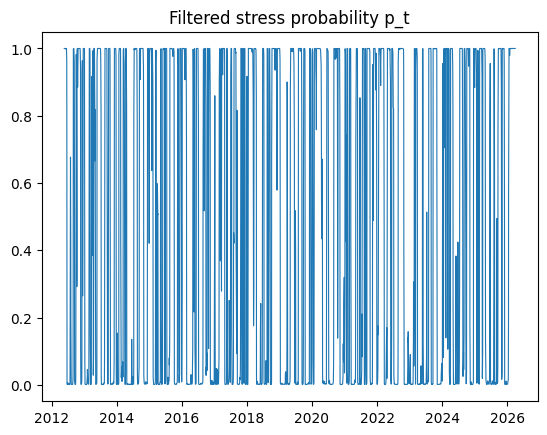

,p_stress
count,3485.000000
mean,0.472927
std,0.468341
min,0.001229
5%,0.001288
50%,0.259875
95%,1.000000
max,1.000000


In [10]:
# Quick diagnostics: distribution and persistence of p_t
fig, ax = plt.subplots()
ax.plot(p_stress.index, p_stress.values, linewidth=0.8)
ax.set_title("Filtered stress probability p_t")
plt.show()

display(p_stress.describe(percentiles=[0.05,0.5,0.95]))


<h3 style="font-weight:700;">6) Fit models</h3>
<ul>
<li><b>Global baseline:</b> PCA on the full training sample.</li>
<li><b>Piecewise baseline:</b> PCA by HMM-informed low/mid/high regimes.</li>
<li><b>Main challenger:</b> calm/stress covariance models blended with the lagged stress probability \(p_{t-1}\).</li>
</ul>


In [11]:
def fit_global_model(ret_train: pd.DataFrame, shrink, k: int) -> dict:
    mu, Sigma = estimate_mu_sigma(ret_train, shrink=shrink)
    pca = pca_on_correlation_arpm(Sigma.values)
    return dict(mu=mu, Sigma=Sigma, pca=pca, k=k)

def fit_regime_models(
    ret_train: pd.DataFrame,
    reg_train_for_ret: pd.Series,
    shrink,
    k: int,
    min_obs: int,
    fallback_global: dict,
) -> dict:
    models = {}
    if reg_train_for_ret is None:
        models["_fallback_global"] = fallback_global
        return models

    for reg in pd.Series(reg_train_for_ret.dropna().unique()).sort_values():
        idx = reg_train_for_ret[reg_train_for_ret == reg].index
        Xr = ret_train.reindex(idx).dropna()
        if len(Xr) < min_obs:
            continue
        mu, Sigma = estimate_mu_sigma(Xr, shrink=shrink)
        pca = pca_on_correlation_arpm(Sigma.values)
        models[str(reg)] = dict(mu=mu, Sigma=Sigma, pca=pca, k=k, n_obs=len(Xr))
    models["_fallback_global"] = fallback_global
    return models


def fit_calm_stress_models(
    ret_train: pd.DataFrame,
    p_train_for_ret: pd.Series,
    shrink,
    k: int,
    min_obs_state: int,
    fallback_global: dict,
    estimation: str = "hard",
    eta_shrink_to_global: float = 0.0,
    shrink_mu_to_global: bool = False,
    p_threshold: float = 0.5,
) -> dict:
    """Estimate calm/stress models.

    estimation:
        - "hard": MAP assignment via p>=p_threshold
        - "weighted": soft assignment via weights (calm: 1-p, stress: p)
    eta_shrink_to_global:
        Sigma_state <- (1-eta)*Sigma_state + eta*Sigma_global (and optionally mu)
    """
    p = p_train_for_ret.astype(float)
    estimation = (estimation or "hard").lower().strip()

    models = {}
    mu_g = fallback_global["mu"]
    Sigma_g = fallback_global["Sigma"]

    if estimation in ("hard", "map", "hard_map"):
        state = pd.Series(index=p.index, dtype=object)
        state[p < p_threshold] = "calm"
        state[p >= p_threshold] = "stress"
        state[p.isna()] = np.nan

        for s in ["calm", "stress"]:
            idx = state[state == s].index
            Xs = ret_train.reindex(idx).dropna()
            if len(Xs) < min_obs_state:
                models[s] = fallback_global
            else:
                mu, Sigma = estimate_mu_sigma(Xs, shrink=shrink)
                mu, Sigma = shrink_params_to_global(mu, Sigma, mu_g, Sigma_g, eta=eta_shrink_to_global, shrink_mu=shrink_mu_to_global)
                pca = pca_on_correlation_arpm(Sigma.values)
                models[s] = dict(mu=mu, Sigma=Sigma, pca=pca, k=k, n_obs=len(Xs))
        models["_state_counts"] = state.value_counts(dropna=False)

    elif estimation in ("weighted", "soft", "soft_assign"):
        w_stress = p.clip(0.0, 1.0)
        w_calm = (1.0 - w_stress).clip(0.0, 1.0)

        for s, w in [("calm", w_calm), ("stress", w_stress)]:
            ww = w.dropna()
            if len(ww) == 0 or float(ww.sum()) <= 0:
                models[s] = fallback_global
                continue
            eff_n = float(ww.sum()) ** 2 / float((ww ** 2).sum() + 1e-12)

            Xs = ret_train.reindex(w.index)
            if eff_n < min_obs_state:
                models[s] = fallback_global
            else:
                mu, Sigma = estimate_mu_sigma_weighted(Xs, w, shrink=shrink)
                mu, Sigma = shrink_params_to_global(mu, Sigma, mu_g, Sigma_g, eta=eta_shrink_to_global, shrink_mu=shrink_mu_to_global)
                pca = pca_on_correlation_arpm(Sigma.values)
                models[s] = dict(mu=mu, Sigma=Sigma, pca=pca, k=k, n_obs=int(eff_n), eff_n=eff_n, sum_w=float(ww.sum()))
        models["_state_counts"] = pd.Series(
            {"calm_weight_sum": float(w_calm.sum()), "stress_weight_sum": float(w_stress.sum())}
        )
    else:
        raise ValueError(f"Unknown estimation='{estimation}'. Use 'hard' or 'weighted'.")

    models["_fallback_global"] = fallback_global
    models["_estimation"] = estimation
    models["_eta_shrink_to_global"] = float(eta_shrink_to_global or 0.0)
    models["_shrink_mu_to_global"] = bool(shrink_mu_to_global)
    return models

# --- fit
global_model = fit_global_model(ret_train, shrink=CONFIG["shrink"], k=CONFIG["k"])

# baseline piecewise PCA (optional)
reg_models = fit_regime_models(
    ret_train=ret_train,
    reg_train_for_ret=reg_train_for_ret,
    shrink=CONFIG["shrink"],
    k=CONFIG["k"],
    min_obs=CONFIG["min_obs_regime"],
    fallback_global=global_model
)

# HMM calm/stress models
cs_models_raw = fit_calm_stress_models(
    ret_train=ret_train,
    p_train_for_ret=p_train_for_ret,
    shrink=CONFIG["shrink"],
    k=CONFIG["k"],
    min_obs_state=CONFIG["min_obs_state"],
    fallback_global=global_model
)

print("Calm/Stress state counts (TRAIN, based on p_{t-1}>=0.5):")
display(cs_models_raw["_state_counts"])

# default alias (may be overwritten later if p-smoothing/model selection is enabled)
cs_models = cs_models_raw


# Convenience aliases (useful for sensitivity tests)
mu_calm   = cs_models["calm"]["mu"]
mu_stress = cs_models["stress"]["mu"]
Sigma_calm   = cs_models["calm"]["Sigma"].values
Sigma_stress = cs_models["stress"]["Sigma"].values


Calm/Stress state counts (TRAIN, based on p_{t-1}>=0.5):


,count
calm,1291
stress,1129
NaN,1


<h3 style="font-weight:700;">7) Static out-of-sample evaluation</h3>
Primary metric: Gaussian NLL (lower is better). PCA reconstruction <code>R^2</code> is reported only as a secondary descriptive metric.

Read this block together with the rolling section later on:
- the table below ranks the models by <b>realized static OOS performance</b>;
- the <b>validation-selected live candidate</b> is reported separately and may differ from the ex-post static winner.

In [12]:
import numpy as np
import pandas as pd

def _get_pca_eig(model: dict):
    """
    Extract eigenvectors/eigenvalues from `model["pca"]`.
    Expected: `model["pca"]["eigvecs"]` has shape (N,N) and `model["pca"]["eigvals"]` has shape (N,)
    """
    p = model["pca"]
    V = np.asarray(p["eigvecs"])
    lam = np.asarray(p["eigvals"]).reshape(-1)
    return V, lam

def pca_reconstruct_from_model(X: pd.DataFrame, model: dict, k=None) -> pd.DataFrame:
    """
    Linear rank-k reconstruction of returns X using the PCA object already stored in the model.
    Note: this is an optional descriptive comparison and does not affect NLL.
    """
    cols = X.columns
    V, lam = _get_pca_eig(model)
    kk = int(k if k is not None else model.get("k", len(cols)))
    kk = max(1, min(kk, V.shape[1], len(cols)))

    # projection onto the subspace spanned by the first k eigenvectors
    Vk = V[:, :kk]                 # N x k
    Xv = X.values                  # T x N
    scores = Xv @ Vk               # T x k
    Xhat = scores @ Vk.T           # T x N
    return pd.DataFrame(Xhat, index=X.index, columns=cols)

def reconstruct_global(ret: pd.DataFrame, global_model: dict, k=None) -> pd.DataFrame:
    return pca_reconstruct_from_model(ret, global_model, k=k)

def reconstruct_piecewise(ret: pd.DataFrame, reg_for_ret: pd.Series, reg_models: dict,
                          k=None, fallback_key: str = "_fallback_global") -> pd.DataFrame:
    """
    Apply reconstruction using the regime-specific model for each date.
    `reg_for_ret` must be indexed like `ret` (same dates).
    """
    yhat = pd.DataFrame(index=ret.index, columns=ret.columns, dtype=float)
    fb = reg_models.get(fallback_key, None)

    for t in ret.index:
        reg = reg_for_ret.loc[t] if t in reg_for_ret.index else np.nan
        key = str(reg) if pd.notna(reg) else None
        m = reg_models.get(key, None)
        if m is None:
            m = fb
        if m is None:
            raise KeyError("Fallback model not found in `reg_models`. Expected key '_fallback_global'.")
        yhat.loc[t:t] = pca_reconstruct_from_model(ret.loc[t:t], m, k=k).values

    return yhat

def r2_total(y: pd.DataFrame, yhat: pd.DataFrame) -> float:
    """
    Panel-wide R²: 1 - SSE/SST over the full stacked panel (all assets together).
    """
    yv = y.values
    yh = yhat.values
    sse = np.sum((yv - yh) ** 2)
    sst = np.sum((yv - np.mean(yv, axis=0, keepdims=True)) ** 2)
    return float(1.0 - sse / sst) if sst > 0 else np.nan

## 6.5) Smoothing on $p_t$ (stress probability) — optional but recommended

We can smooth the regime probability *before* using it as mixture weight / for calm–stress assignment.

Why: the filtered HMM probability can be noisy, which may induce unstable calm/stress splits and unstable mixture weights.

The smoother is selected only on a **validation slice inside TRAIN**. The notebook also reports the best realized static OOS model separately, but that diagnostic is **not** used for selection.


In [13]:
# ----------------------------
# 6.5) p_t smoothing / calibration (objective)
# ----------------------------

def smooth_p_series(p: pd.Series, method: str, param=None, pbar=None) -> pd.Series:
    """
    Smooth a probability series p_t in [0,1].

    Methods
    -------
    none:
        no change
    shrink_to_mean (alpha in [0,1]):
        p' = (1-alpha)*p + alpha*pbar    where pbar is computed on TRAIN (not on TEST)
    temperature (T>0):
        p' = sigmoid( logit(p) / T )
        - T>1 makes p less extreme (closer to 0.5), T<1 makes it sharper
    ema (gamma in [0,1)):
        p'_t = gamma*p'_{t-1} + (1-gamma)*p_t   (low-pass filter)
    """
    if p is None:
        return p
    p = p.astype(float).copy()
    eps = 1e-6
    p = p.clip(eps, 1 - eps)

    method = (method or "none").lower()

    if method in ("none", "raw"):
        return p

    if method in ("shrink_to_mean", "shrink", "shrink_to_train_mean"):
        if param is None:
            raise ValueError("shrink_to_mean needs param=alpha in [0,1].")
        if pbar is None or np.isnan(pbar):
            raise ValueError("shrink_to_mean needs pbar (TRAIN mean).")
        alpha = float(param)
        return (1 - alpha) * p + alpha * float(pbar)

    if method in ("temperature", "temp", "logit_temperature"):
        if param is None:
            raise ValueError("temperature needs param=T > 0.")
        T = float(param)
        if T <= 0:
            raise ValueError("T must be > 0.")
        x = np.log(p.values / (1 - p.values))
        x = x / T
        out = 1 / (1 + np.exp(-x))
        return pd.Series(out, index=p.index)

    if method in ("ema", "ewma", "exp_smooth"):
        if param is None:
            raise ValueError("ema needs param=gamma in [0,1).")
        gamma = float(param)
        if not (0 <= gamma < 1):
            raise ValueError("gamma must be in [0,1).")
        out = p.copy()
        first = out.first_valid_index()
        if first is None:
            return out
        y_prev = float(out.loc[first])
        start_pos = out.index.get_loc(first)
        for t in out.index[start_pos:]:
            x = float(out.loc[t])
            y = gamma * y_prev + (1 - gamma) * x
            out.loc[t] = y
            y_prev = y
        return out

    raise ValueError(f"Unknown smoothing method: {method}")


def mean_nll_mix_on_slice(
    ret_slice: pd.DataFrame,
    p_for_ret_slice: pd.Series,
    cs_models_slice: dict,
) -> float:
    Sigma_calm = cs_models_slice["calm"]["Sigma"].values
    Sigma_stress = cs_models_slice["stress"]["Sigma"].values
    mu_calm = cs_models_slice["calm"]["mu"].values
    mu_stress = cs_models_slice["stress"]["mu"].values
    return float(nll_hmm_mixture_given_p(ret_slice, p_for_ret_slice, Sigma_calm, Sigma_stress, mu_calm, mu_stress).mean())


# -------------------------------------------------------
# (A) Optional selection inside TRAIN (FIT + VAL)
# -------------------------------------------------------

P_SMOOTHER = {"method": "none", "param": None, "pbar_train": float(p_train_for_ret.dropna().mean())}

# We select (via VAL) to reduce discretion:
# - p-smoother (method + param)
# - calm/stress estimation method: hard vs weighted
# - eta shrink-to-global for calm/stress parameters
# - model family: "mixture" vs "volmix_corrfixed"
SELECTED = {
    "p_smoother": dict(P_SMOOTHER),
    "cs_estimation": "hard",
    "eta_shrink_to_global": 0.0,
    "model_family": "mixture",
    "shrink_mu_to_global": bool(CONFIG.get("shrink_mu_to_global", False)),
}

if CONFIG.get("do_model_selection", True) and (CONFIG.get("p_smoothing_method", "auto").lower() == "auto"):

    train_idx = ret_train.index
    train_end_dt = train_idx.max()
    val_years = int(CONFIG.get("val_years", 1))
    cut_dt = train_end_dt - pd.DateOffset(years=val_years)

    fit_idx = train_idx[train_idx <= cut_dt]
    val_idx = train_idx[train_idx > cut_dt]

    if len(val_idx) < 60 or len(fit_idx) < 252:
        print("WARN: validation split too small; falling back to defaults (no selection).")
    else:
        # 1) Refit HMM on FIT z only (no leakage), then compute p on FIT+VAL
        z_fit = z.reindex(fit_idx).dropna()
        hmm_params_sel = hmm_fit_gaussian_1d(
            z_fit,
            n_states=CONFIG["hmm_n_states"],
            max_iter=CONFIG["hmm_max_iter"],
            tol=CONFIG["hmm_tol"],
            var_floor=CONFIG["hmm_var_floor"],
            seed=CONFIG["hmm_seed"],
        )

        z_fitval = z.reindex(fit_idx.union(val_idx)).dropna()
        filt_sel = hmm_filter_probs(z_fitval, hmm_params_sel)
        p_sel = hmm_stress_probability(filt_sel, hmm_params_sel)

        p_fit_for_ret = p_sel.shift(1).reindex(fit_idx)
        p_val_for_ret = p_sel.shift(1).reindex(val_idx)

        # 2) Fit global on FIT only
        global_fit = fit_global_model(ret_train.reindex(fit_idx), shrink=CONFIG["shrink"], k=CONFIG["k"])
        fallback_fit = global_fit

        # baseline (global) on VAL
        nll_global_val = float(gaussian_nll_mean_global(ret_train.reindex(val_idx), global_fit))

        pbar_fit = float(p_fit_for_ret.dropna().mean())

        # Candidate grids
        candidates = [("none", None)]
        candidates += [("shrink_to_mean", a) for a in CONFIG.get("p_smoothing_alpha_grid", [0.0, 0.25, 0.5, 0.75, 0.9, 1.0])]
        candidates += [("temperature", T) for T in CONFIG.get("p_smoothing_T_grid", [0.75, 1.0, 1.25, 1.5, 2.0, 3.0])]
        candidates += [("ema", g) for g in CONFIG.get("p_smoothing_gamma_grid", [0.0, 0.25, 0.5, 0.75, 0.9])]

        eta_grid = CONFIG.get("eta_shrink_to_global_grid", [0.0, 0.25, 0.5, 0.75, 0.9])
        est_grid = CONFIG.get("cs_estimation_grid", ["hard", "weighted"])
        fam_grid = CONFIG.get("model_family_grid", ["mixture", "volmix_corrfixed"])

        rows = []
        for method, param in candidates:
            # Smooth FIT p (for calm/stress estimation)
            p_fit_s = smooth_p_series(p_fit_for_ret, method, param, pbar=pbar_fit)
            # Smooth VAL p (for mixture weights)
            p_val_s = smooth_p_series(p_val_for_ret, method, param, pbar=pbar_fit)

            for est in est_grid:
                for eta in eta_grid:
                    cs_fit = fit_calm_stress_models(
                        ret_train=ret_train.reindex(fit_idx),
                        p_train_for_ret=p_fit_s,
                        shrink=CONFIG["shrink"],
                        k=CONFIG["k"],
                        min_obs_state=CONFIG["min_obs_state"],
                        fallback_global=fallback_fit,
                        estimation=est,
                        eta_shrink_to_global=float(eta),
                        shrink_mu_to_global=bool(CONFIG.get("shrink_mu_to_global", False)),
                    )

                    for fam in fam_grid:
                        if fam == "mixture":
                            nll_val = float(gaussian_nll_mean_mixture(
                                ret_train.reindex(val_idx),
                                p_val_s,
                                cs_fit["calm"],
                                cs_fit["stress"],
                                fallback_model=fallback_fit,
                                ridge_mult=CONFIG["ridge_mult"],
                            ))
                        elif fam == "volmix_corrfixed":
                            nll_val = float(gaussian_nll_mean_volmix_corrfixed(
                                ret_train.reindex(val_idx),
                                p_val_s,
                                cs_fit["calm"],
                                cs_fit["stress"],
                                fallback_model=fallback_fit,
                                ridge_mult=CONFIG["ridge_mult"],
                            ))
                        else:
                            raise ValueError(f"Unknown model family: {fam}")

                        rows.append((
                            fam, est, float(eta), method, (None if param is None else float(param)),
                            nll_val, float(nll_val - nll_global_val)
                        ))

        sel = pd.DataFrame(
            rows,
            columns=["model_family","cs_estimation","eta_shrink_to_global","p_method","p_param","mean_nll_val","delta_vs_global_val"],
        ).sort_values("mean_nll_val")

        display(sel.head(20))

        best = sel.iloc[0]
        SELECTED = {
            "p_smoother": {"method": str(best["p_method"]), "param": (None if pd.isna(best["p_param"]) else float(best["p_param"])), "pbar_train": pbar_fit},
            "cs_estimation": str(best["cs_estimation"]),
            "eta_shrink_to_global": float(best["eta_shrink_to_global"]),
            "model_family": str(best["model_family"]),
            "shrink_mu_to_global": bool(CONFIG.get("shrink_mu_to_global", False)),
        }
        P_SMOOTHER = dict(SELECTED["p_smoother"])
        print("Validation-selected configuration:", SELECTED)

else:
    # manual choice (no tuning)
    m = CONFIG.get("p_smoothing_method", "none")
    P_SMOOTHER = {"method": m, "param": None, "pbar_train": float(p_train_for_ret.dropna().mean())}
    SELECTED["p_smoother"] = dict(P_SMOOTHER)
    SELECTED["cs_estimation"] = str(CONFIG.get("cs_estimation_grid", ["hard"])[0])
    SELECTED["eta_shrink_to_global"] = float(CONFIG.get("eta_shrink_to_global_grid", [0.0])[0])
    SELECTED["model_family"] = str(CONFIG.get("model_family_grid", ["mixture"])[0])
    print("Using selection (manual):", SELECTED)

# -------------------------------------------------------
# (B) Refit calm/stress models on FULL TRAIN using the chosen smoother + eta + estimation
# -------------------------------------------------------
pbar_train_full = float(p_train_for_ret.dropna().mean())
P_SMOOTHER["pbar_train"] = pbar_train_full
SELECTED["p_smoother"]["pbar_train"] = pbar_train_full

p_train_for_ret_used = smooth_p_series(p_train_for_ret, P_SMOOTHER["method"], P_SMOOTHER["param"], pbar=pbar_train_full)
p_test_for_ret_used  = smooth_p_series(p_test_for_ret,  P_SMOOTHER["method"], P_SMOOTHER["param"], pbar=pbar_train_full)

cs_models = fit_calm_stress_models(
    ret_train=ret_train,
    p_train_for_ret=p_train_for_ret_used,
    shrink=CONFIG["shrink"],
    k=CONFIG["k"],
    min_obs_state=CONFIG["min_obs_state"],
    fallback_global=global_model,
    estimation=SELECTED["cs_estimation"],
    eta_shrink_to_global=SELECTED["eta_shrink_to_global"],
    shrink_mu_to_global=SELECTED.get("shrink_mu_to_global", False),
)

print("Calm/Stress state counts (TRAIN) — after smoothing + selection:")
display(cs_models["_state_counts"])
print("Selected model family:", SELECTED["model_family"])


,model_family,cs_estimation,eta_shrink_to_global,p_method,p_param,mean_nll_val,delta_vs_global_val
101,volmix_corrfixed,hard,0.00,shrink_to_mean,0.90,-188.687552,-0.078942
103,volmix_corrfixed,hard,0.25,shrink_to_mean,0.90,-188.672091,-0.063481
70,mixture,weighted,0.00,shrink_to_mean,0.50,-188.659656,-0.051046
83,volmix_corrfixed,hard,0.25,shrink_to_mean,0.75,-188.659529,-0.050919
73,volmix_corrfixed,weighted,0.25,shrink_to_mean,0.50,-188.658465,-0.049855
85,volmix_corrfixed,hard,0.50,shrink_to_mean,0.75,-188.655319,-0.046708
105,volmix_corrfixed,hard,0.50,shrink_to_mean,0.90,-188.653631,-0.045021
75,volmix_corrfixed,weighted,0.50,shrink_to_mean,0.50,-188.652883,-0.044273
72,mixture,weighted,0.25,shrink_to_mean,0.50,-188.649816,-0.041206
71,volmix_corrfixed,weighted,0.00,shrink_to_mean,0.50,-188.649450,-0.040840


Validation-selected configuration: {'p_smoother': {'method': 'shrink_to_mean', 'param': 0.9, 'pbar_train': 0.457078296794146}, 'cs_estimation': 'hard', 'eta_shrink_to_global': 0.0, 'model_family': 'volmix_corrfixed', 'shrink_mu_to_global': False}
Calm/Stress state counts (TRAIN) — after smoothing + selection:


,count
calm,1396
stress,1024
NaN,1


Selected model family: volmix_corrfixed


In [14]:
# --- PCA reconstruction (optional comparison)
yhat_g = reconstruct_global(ret_test, global_model)

if CONFIG["do_piecewise_pca"]:
    yhat_pw = reconstruct_piecewise(ret_test, reg_test_for_ret, reg_models)
else:
    yhat_pw = None

print("Global PCA R2_total (test):", r2_total(ret_test, yhat_g))

if yhat_pw is not None:
    print("Piecewise PCA R2_total (test):", r2_total(ret_test, yhat_pw))


Global PCA R2_total (test): 0.4690815930697845
Piecewise PCA R2_total (test): 0.46605086102601445


In [15]:

# --- Main NLL comparisons (static OOS)
nll_global = gaussian_nll_mean_global(ret_test, global_model, ridge_mult=CONFIG["ridge_mult"])

if CONFIG["do_piecewise_pca"]:
    nll_piecewise = gaussian_nll_mean_piecewise(
        ret_test.reset_index(drop=True),
        reg_test_for_ret.reset_index(drop=True),
        reg_models,
        fallback_model=global_model,
        ridge_mult=CONFIG["ridge_mult"],
    )
else:
    nll_piecewise = np.nan

nll_hmm_mix = gaussian_nll_mean_mixture(
    ret_test.reset_index(drop=True),
    p_test_for_ret_used.reset_index(drop=True),
    cs_models["calm"],
    cs_models["stress"],
    fallback_model=global_model,
    ridge_mult=CONFIG["ridge_mult"],
)

if CONFIG.get("do_volmix_corrfixed", True):
    nll_volmix = gaussian_nll_mean_volmix_corrfixed(
        ret_test.reset_index(drop=True),
        p_test_for_ret_used.reset_index(drop=True),
        cs_models["calm"],
        cs_models["stress"],
        fallback_model=global_model,
        ridge_mult=CONFIG["ridge_mult"],
    )
else:
    nll_volmix = np.nan

validation_selected_label = (
    "HMM Mixture (validation-selected)"
    if SELECTED.get("model_family", "mixture") == "mixture"
    else "Vol-mix Corr-fixed (validation-selected)"
)

summary = pd.DataFrame(
    {
        "mean_nll": [nll_global, nll_piecewise, nll_hmm_mix, nll_volmix],
        "delta_vs_global": [0.0, nll_piecewise - nll_global, nll_hmm_mix - nll_global, nll_volmix - nll_global],
        "selected_in_train_validation": [
            False,
            False,
            validation_selected_label.startswith("HMM"),
            validation_selected_label.startswith("Vol-mix"),
        ],
    },
    index=[
        "Global (static)",
        "Piecewise PCA (HMM-informed thresholds)",
        "HMM Mixture (calm/stress)",
        "Vol-mix Corr-fixed (calm/stress)",
    ],
)

summary = summary.sort_values("mean_nll")
display(summary)

static_oos_winner = summary.index[0]
print("Validation-selected family:", validation_selected_label)
print("Best realized static OOS model (diagnostic only):", static_oos_winner)

if np.isfinite(nll_piecewise):
    print("Δ Mean NLL piecewise - global:", float(nll_piecewise - nll_global))
print("Δ Mean NLL HMM-mixture - global:", float(nll_hmm_mix - nll_global))
print("Δ Mean NLL Vol-mix (corr-fixed) - global:", float(nll_volmix - nll_global))


,mean_nll,delta_vs_global,selected_in_train_validation
HMM Mixture (calm/stress),-175.977512,-0.370490,False
Vol-mix Corr-fixed (calm/stress),-175.654812,-0.047790,True
Global (static),-175.607022,0.000000,False
Piecewise PCA (HMM-informed thresholds),-175.040665,0.566357,False


Validation-selected family: Vol-mix Corr-fixed (validation-selected)
Best realized static OOS model (diagnostic only): HMM Mixture (calm/stress)
Δ Mean NLL piecewise - global: 0.5663571029537309
Δ Mean NLL HMM-mixture - global: -0.3704900361938144
Δ Mean NLL Vol-mix (corr-fixed) - global: -0.047790050199466805


**Current V2 run — how to read the static table**

- **Validation-selected live candidate:** Vol-mix Corr-fixed  
- **Best realized static OOS model (diagnostic only):** HMM Mixture  
- **Global static mean NLL:** -175.607  
- **HMM mixture mean NLL:** -175.978 (**Δ vs global = -0.370**)  
- **Vol-mix Corr-fixed mean NLL:** -175.655 (**Δ vs global = -0.048**)  
- **Piecewise PCA mean NLL:** -175.041 (**Δ vs global = +0.566**)

So, in the current broad-US V2 run, the HMM mixture is the strongest **static** challenger, while the train/validation-selected live candidate remains Vol-mix Corr-fixed.

In [16]:
# --- NLL parts diagnostic (logdet vs quad)
# NOTE: here we use a *constant* pbar (average p on test) to build (mu_bar, Sigma_bar).
# This is ONLY a diagnostic decomposition (logdet vs quad). It is NOT the same as the dynamic HMM-mixture NLL,
# which uses time-varying p_t day-by-day. They coincide only if p_t is constant.
# For interpretability: compute average Sigma under mixture by using average p on test.
pbar = float(np.nanmean(p_test_for_ret_used.values))
Sigma_bar = (1-pbar)*cs_models["calm"]["Sigma"].values + pbar*cs_models["stress"]["Sigma"].values
mu_bar = (1-pbar)*cs_models["calm"]["mu"].values + pbar*cs_models["stress"]["mu"].values

ld_g, q_g = nll_parts(ret_test.astype(float), global_model["mu"].values, global_model["Sigma"].values, ridge_mult=CONFIG["ridge_mult"])
ld_m, q_m = nll_parts(ret_test.astype(float), mu_bar, Sigma_bar, ridge_mult=CONFIG["ridge_mult"])

pd.DataFrame(
    {
        "mean_logdet": [ld_g, ld_m],
        "mean_quad":   [q_g, q_m],
        "mean_nll":    [ld_g+q_g, ld_m+q_m],
    },
    index=["Global (static)", "HMM mixture (using avg p)"]
)


,mean_logdet,mean_quad,mean_nll
Global (static),-213.802222,38.19520,-175.607022
HMM mixture (using avg p),-213.158729,37.22329,-175.935439


## 6. Sensitivity: smoothing the regime signal $p_t$

If the **dynamic** mixture underperforms, it may be because $p_t$ is too noisy or too extreme.
Here we test two simple regularizations:

1. **Shrink to mean:** $p^{(\alpha)}_t = (1-\alpha)p_t + \alpha\bar p$
2. **Temperature scaling:** $p^{(T)}_t = \sigma(\operatorname{logit}(p_t)/T)$
3. **EMA smoothing:** a low-pass filter on the probability path

This block is a diagnostic sensitivity analysis on the **test set**. It is **not** a model-selection step.


In [17]:
# Sensitivity checks on TEST — how a noisy p_t helps or hurts.
# NOTE: this is a test-set diagnostic. Do NOT use it for model selection.

def nll_mix_test(p_for_ret: pd.Series) -> float:
    """Mean Gaussian NLL for HMM-mixture on TEST given an external p_t series."""
    p_al = p_for_ret.reindex(ret_test.index)
    return float(
        gaussian_nll_mean_mixture(
            ret_test,
            p_al,
            model_calm=cs_models["calm"],
            model_stress=cs_models["stress"],
            fallback_model=global_model,
            ridge_mult=CONFIG.get("ridge_mult", 1e-3),
        )
    )

# baseline global (static)
nll_global_test = float(
    gaussian_nll_mean_global(
        ret_test,
        model=global_model,
        ridge_mult=CONFIG.get("ridge_mult", 1e-3),
    )
)

print("Validation-selected p-smoother:", P_SMOOTHER)
print("Global mean NLL (TEST):", nll_global_test)

pbar_train = float(p_train_for_ret.dropna().mean())

# --- shrink-to-mean grid (to TRAIN mean)
rows = []
for a in CONFIG.get("p_smoothing_alpha_grid", [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]):
    p_sh = smooth_p_series(p_test_for_ret, "shrink_to_mean", float(a), pbar=pbar_train)
    nll = nll_mix_test(p_sh)
    rows.append((a, nll, nll - nll_global_test))
alpha_tbl = pd.DataFrame(rows, columns=["alpha", "mean_nll", "delta_vs_global"]).sort_values("mean_nll")
display(alpha_tbl)

# --- temperature scaling grid
rows = []
for T in CONFIG.get("p_smoothing_T_grid", [0.75, 1.0, 1.25, 1.5, 2.0, 3.0]):
    pT = smooth_p_series(p_test_for_ret, "temperature", float(T), pbar=pbar_train)
    nll = nll_mix_test(pT)
    rows.append((T, nll, nll - nll_global_test))
T_tbl = pd.DataFrame(rows, columns=["T", "mean_nll", "delta_vs_global"]).sort_values("mean_nll")
display(T_tbl)

# --- EMA smoothing grid
rows = []
for g in CONFIG.get("p_smoothing_gamma_grid", [0.0, 0.25, 0.5, 0.75, 0.9]):
    pE = smooth_p_series(p_test_for_ret, "ema", float(g), pbar=pbar_train)
    nll = nll_mix_test(pE)
    rows.append((g, nll, nll - nll_global_test))
G_tbl = pd.DataFrame(rows, columns=["gamma", "mean_nll", "delta_vs_global"]).sort_values("mean_nll")
display(G_tbl)

Validation-selected p-smoother: {'method': 'shrink_to_mean', 'param': 0.9, 'pbar_train': 0.4663134489577213}
Global mean NLL (TEST): -175.60702171372253


,alpha,mean_nll,delta_vs_global
3,0.75,-176.014650,-0.407628
4,0.90,-175.977512,-0.370490
2,0.50,-175.974776,-0.367755
5,1.00,-175.927194,-0.320172
1,0.25,-175.793929,-0.186907
0,0.00,-175.417215,0.189806


,T,mean_nll,delta_vs_global
5,3.00,-175.997935,-0.390914
4,2.00,-175.739171,-0.132150
3,1.50,-175.575999,0.031023
2,1.25,-175.494650,0.112371
1,1.00,-175.417215,0.189806
0,0.75,-175.342859,0.264163


,gamma,mean_nll,delta_vs_global
4,0.90,-175.848017,-0.240995
3,0.75,-175.652185,-0.045163
2,0.50,-175.516862,0.090159
1,0.25,-175.460990,0.146032
0,0.00,-175.417215,0.189806


<h3 style="font-weight:700;">8) Visual diagnostics</h3>
Plots for the state variable, the filtered stress probability, their relationship, and regime counts.


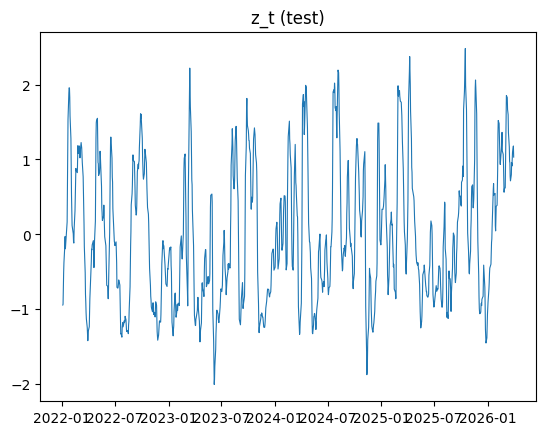

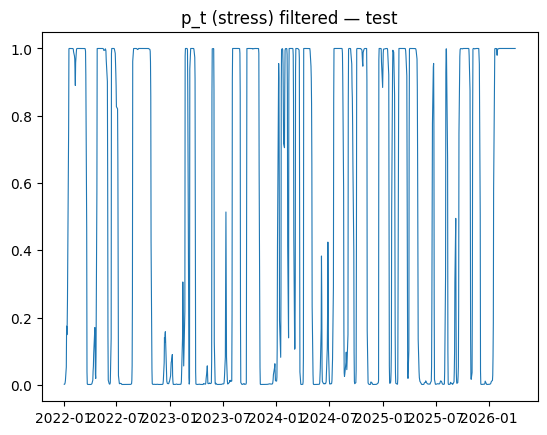

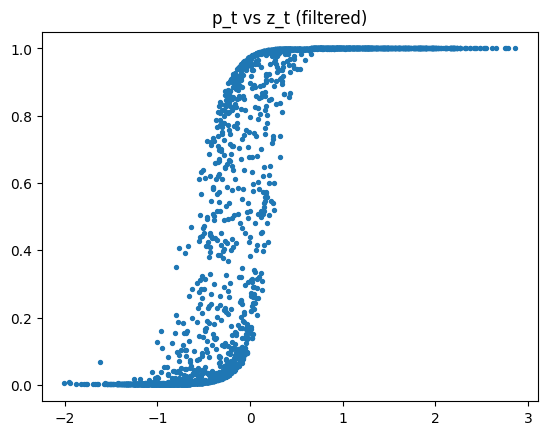

,count
calm,552
stress,512


In [18]:
# z and p on test
fig, ax = plt.subplots()
ax.plot(z.reindex(ret_test.index).index, z.reindex(ret_test.index).values, linewidth=0.8)
ax.set_title("z_t (test)")
plt.show()

fig, ax = plt.subplots()
ax.plot(p_stress.reindex(ret_test.index).index, p_stress.reindex(ret_test.index).values, linewidth=0.8)
ax.set_title("p_t (stress) filtered — test")
plt.show()

# scatter p vs z
tmp = pd.DataFrame({"z": z_eval, "p": p_stress.reindex(z_eval.index)}).dropna()
fig, ax = plt.subplots()
ax.scatter(tmp["z"], tmp["p"], s=8)
ax.set_title("p_t vs z_t (filtered)")
plt.show()

# state counts in test (MAP from p_{t-1})
p = p_test_for_ret.astype(float)
state_test = pd.Series(index=p.index, dtype=object)
state_test[p < 0.5] = "calm"
state_test[p >= 0.5] = "stress"
state_test[p.isna()] = np.nan
display(state_test.value_counts(dropna=False))


<h3 style="font-weight:700;">9) Block bootstrap — distribution of ΔNLL</h3>
Use moving-block bootstrap on the test set to estimate the distribution of:
- ΔmeanNLL (HMM-mixture − global)
- ΔmeanNLL (vol-mix − global)
- ΔmeanNLL (piecewise − global)

This section measures robustness of the static OOS comparison; it is not a model-selection step.

,delta_mean_NLL_mix_minus_global,delta_mean_NLL_volmix_minus_global,delta_mean_NLL_piecewise_minus_global
count,300.000000,300.000000,300.000000
mean,-0.362783,-0.040043,0.597467
std,0.072724,0.086154,0.357160
min,-0.576685,-0.328791,-0.541580
5%,-0.483259,-0.172571,0.035100
50%,-0.354537,-0.040987,0.591270
95%,-0.255363,0.093575,1.149352
max,-0.171495,0.228065,1.663895


P( HMM-mixture beats global ) = 1.0
P( Vol-mix Corr-fixed beats global ) = 0.6733333333333333
P( piecewise beats global ) = 0.05


,p_win (Δ<0),p_lose (Δ>0),avg_win |Δ| (if win),avg_loss Δ (if lose),EV improvement = E[-Δ],Omega (sum gains / sum losses)
HMM-mixture vs global,1.0,0.0,0.362783,NaN,0.362783,NaN


,p_win (Δ<0),p_lose (Δ>0),avg_win |Δ| (if win),avg_loss Δ (if lose),EV improvement = E[-Δ],Omega (sum gains / sum losses)
Vol-mix Corr-fixed vs global,0.673333,0.326667,0.085586,0.053833,0.040043,3.277065


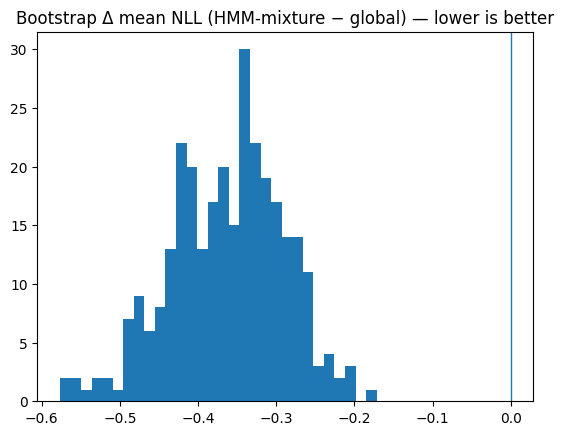

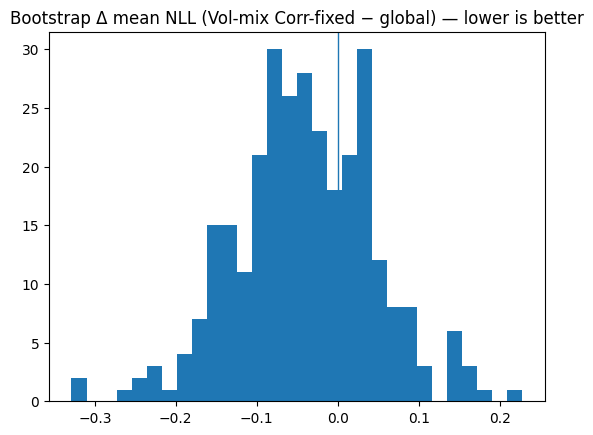

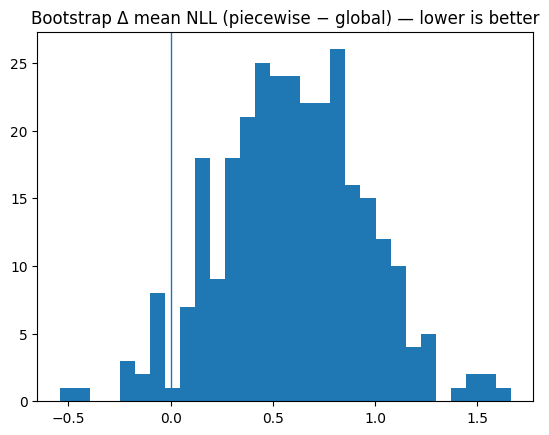

In [19]:
# ----------------------------
# 9) Bootstrap: compare mean NLL deltas (mixture / vol-mix / piecewise) vs global
# ----------------------------
def moving_block_bootstrap_indices(n: int, block: int, rng: np.random.Generator) -> np.ndarray:
    if block < 1:
        raise ValueError("block must be >= 1")
    block = min(block, n)
    m = int(np.ceil(n / block))
    starts = rng.integers(0, n - block + 1, size=m)
    idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
    return idx

def bootstrap_deltas_nll(
    ret_test: pd.DataFrame,
    p_test_for_ret: pd.Series,
    global_model: dict,
    cs_models: dict,
    reg_test_for_ret=None,
    reg_models=None,
    B: int = 300,
    block: int = 20,
    seed: int = 7,
    ridge_mult: float = 1e-3,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = len(ret_test)
    out = []

    for _ in range(B):
        idx = moving_block_bootstrap_indices(n, block, rng)

        y = ret_test.iloc[idx].reset_index(drop=True)
        p = p_test_for_ret.iloc[idx].reset_index(drop=True)

        nll_g = gaussian_nll_mean_global(y, global_model, ridge_mult=ridge_mult)

        nll_mix = gaussian_nll_mean_mixture(
            y, p,
            cs_models["calm"], cs_models["stress"],
            fallback_model=global_model,
            ridge_mult=ridge_mult
        )

        nll_volmix = gaussian_nll_mean_volmix_corrfixed(
            y, p,
            cs_models["calm"], cs_models["stress"],
            fallback_model=global_model,
            ridge_mult=ridge_mult
        )

        row = {
            "delta_mean_NLL_mix_minus_global": float(nll_mix - nll_g),
            "delta_mean_NLL_volmix_minus_global": float(nll_volmix - nll_g),
        }

        if (reg_test_for_ret is not None) and (reg_models is not None) and CONFIG["do_piecewise_pca"]:
            reg = reg_test_for_ret.iloc[idx].reset_index(drop=True)
            nll_pw = gaussian_nll_mean_piecewise(
                y, reg,
                reg_models=reg_models,
                fallback_model=global_model,
                ridge_mult=ridge_mult
            )
            row["delta_mean_NLL_piecewise_minus_global"] = float(nll_pw - nll_g)

        out.append(row)

    return pd.DataFrame(out)

def win_loss_table(delta: pd.Series, name: str) -> pd.DataFrame:
    d = delta.astype(float)
    p_win  = float((d < 0).mean())
    p_lose = float((d > 0).mean())
    win_mag  = (-d[d < 0])  # positive improvements
    loss_mag = ( d[d > 0])  # positive deteriorations

    avg_win  = float(win_mag.mean())  if len(win_mag)  else np.nan
    avg_loss = float(loss_mag.mean()) if len(loss_mag) else np.nan

    ev_impr = float((-d).mean())  # E[-Δ], positive means improvement on avg
    omega = float(win_mag.sum() / loss_mag.sum()) if (len(win_mag) and len(loss_mag) and loss_mag.sum() > 0) else np.nan

    return pd.DataFrame({
        "p_win (Δ<0)": [p_win],
        "p_lose (Δ>0)": [p_lose],
        "avg_win |Δ| (if win)": [avg_win],
        "avg_loss Δ (if lose)": [avg_loss],
        "EV improvement = E[-Δ]": [ev_impr],
        "Omega (sum gains / sum losses)": [omega],
    }, index=[name])

if CONFIG["do_bootstrap"]:
    boot = bootstrap_deltas_nll(
        ret_test=ret_test,
        p_test_for_ret=p_test_for_ret_used,
        global_model=global_model,
        cs_models=cs_models,
        reg_test_for_ret=reg_test_for_ret if CONFIG["do_piecewise_pca"] else None,
        reg_models=reg_models if CONFIG["do_piecewise_pca"] else None,
        B=CONFIG["bootstrap_B"],
        block=CONFIG["bootstrap_block"],
        seed=CONFIG.get("bootstrap_seed", 7),
        ridge_mult=CONFIG["ridge_mult"],
    )

    display(boot.describe(percentiles=[0.05, 0.5, 0.95]))

    print("P( HMM-mixture beats global ) =", float((boot["delta_mean_NLL_mix_minus_global"] < 0).mean()))
    print("P( Vol-mix Corr-fixed beats global ) =", float((boot["delta_mean_NLL_volmix_minus_global"] < 0).mean()))
    if "delta_mean_NLL_piecewise_minus_global" in boot.columns:
        print("P( piecewise beats global ) =", float((boot["delta_mean_NLL_piecewise_minus_global"] < 0).mean()))

    display(win_loss_table(boot["delta_mean_NLL_mix_minus_global"], "HMM-mixture vs global"))
    display(win_loss_table(boot["delta_mean_NLL_volmix_minus_global"], "Vol-mix Corr-fixed vs global"))

    fig, ax = plt.subplots()
    ax.hist(boot["delta_mean_NLL_mix_minus_global"], bins=30)
    ax.axvline(0, linewidth=1)
    ax.set_title("Bootstrap Δ mean NLL (HMM-mixture − global) — lower is better")
    plt.show()

    fig, ax = plt.subplots()
    ax.hist(boot["delta_mean_NLL_volmix_minus_global"], bins=30)
    ax.axvline(0, linewidth=1)
    ax.set_title("Bootstrap Δ mean NLL (Vol-mix Corr-fixed − global) — lower is better")
    plt.show()

    if "delta_mean_NLL_piecewise_minus_global" in boot.columns:
        fig, ax = plt.subplots()
        ax.hist(boot["delta_mean_NLL_piecewise_minus_global"], bins=30)
        ax.axvline(0, linewidth=1)
        ax.set_title("Bootstrap Δ mean NLL (piecewise − global) — lower is better")
        plt.show()


## 10) Rolling recalibration (walk-forward)

Goal: emulate a live workflow where the model is periodically refit using only past data.

At each refit date:
1. Fit the **global** model on a trailing return window.
2. Fit the **HMM** on the trailing window of the state variable $z_t$.
3. Estimate calm/stress return models using lagged probabilities.
4. Score the next period until the following refit with filtered probabilities only.

This section is the cleanest proxy for live deployment. In the current executed run, the rolling global benchmark remains slightly better than the regime-aware challengers, so the static and rolling results should be interpreted separately.

,Mean NLL
Global static,-175.607022
HMM-mixture static,-175.417216
Vol-mix Corr-fixed static,-173.812192
Global rolling,-179.421569
HMM-mixture rolling,-179.397980
Vol-mix Corr-fixed rolling,-179.329026


Δ Mean NLL (rolling mix - rolling global): 0.02358903322956373
Δ Mean NLL (rolling vol-mix - rolling global): 0.09254343180898844


,boot_mean_delta_mix_minus_global,boot_mean_delta_volmix_minus_global
count,300.000000,300.000000
mean,0.027323,0.087553
std,0.026742,0.055427
min,-0.048912,-0.050463
5%,-0.014705,0.001220
50%,0.026272,0.086052
95%,0.075983,0.185250
max,0.098243,0.233040


P( rolling mixture beats rolling global ) = 0.13333333333333333
P( rolling vol-mix beats rolling global ) = 0.05


,p_win (Δ<0),p_lose (Δ>0),avg_win |Δ| (if win),avg_loss Δ (if lose),EV improvement = E[-Δ],Omega (sum gains / sum losses)
rolling mix vs rolling global,0.133333,0.866667,0.014260,0.03372,-0.027323,0.065059
rolling vol-mix vs rolling global,0.050000,0.950000,0.019162,0.09317,-0.087553,0.010825


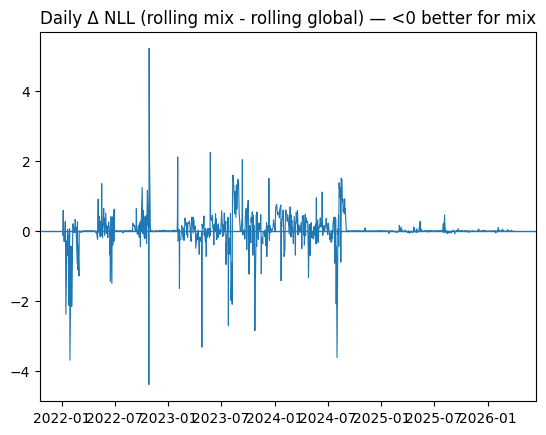

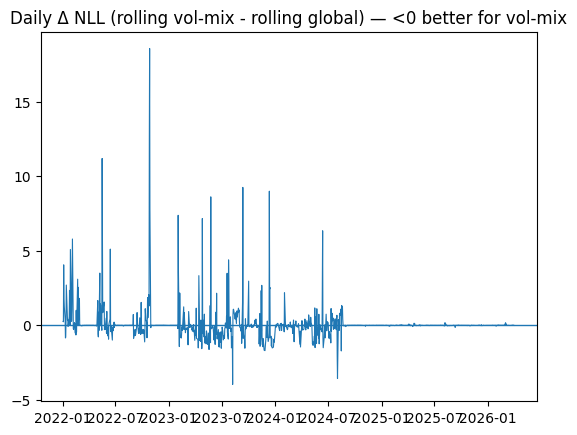

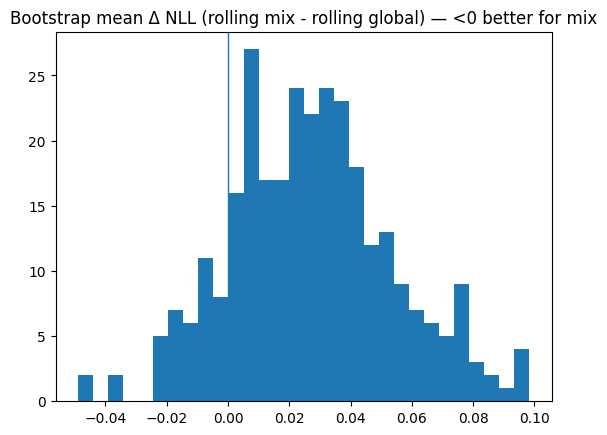

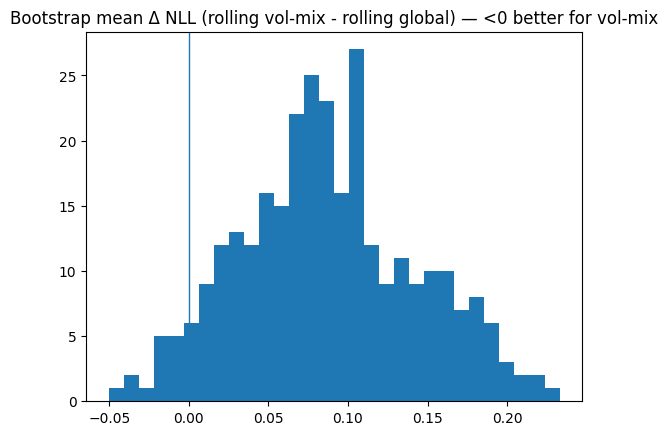

In [20]:
# ----------------------------
# 10) Rolling recalibration (walk-forward template)
# ----------------------------
def gaussian_nll_series_global(rets: pd.DataFrame, model: dict, ridge_mult: float = 1e-3) -> pd.Series:
    R = rets.astype(float)
    cols = R.columns

    mu = model["mu"].reindex(cols).astype(float).values
    Sigma = model["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        S = S + 1e-2*np.eye(S.shape[0])
        sign, logdet = np.linalg.slogdet(S)

    out = np.empty(len(R), dtype=float)
    for i in range(len(R)):
        x = R.values[i] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)
    return pd.Series(out, index=R.index, name="nll_global")

def gaussian_nll_series_mixture(
    rets: pd.DataFrame,
    p_stress_lagged: pd.Series,
    model_calm: dict,
    model_stress: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3
) -> pd.Series:
    Rdf = rets.astype(float)
    cols = Rdf.columns
    R = Rdf.values
    p = p_stress_lagged.reindex(Rdf.index).astype(float).values

    mu_c = model_calm["mu"].reindex(cols).astype(float).values
    mu_s = model_stress["mu"].reindex(cols).astype(float).values
    Sc = model_calm["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Ss = model_stress["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    mu_g = fallback_model["mu"].reindex(cols).astype(float).values
    Sg = fallback_model["Sigma"].reindex(index=cols, columns=cols).astype(float).values

    out = np.empty(len(Rdf), dtype=float)
    for i in range(len(Rdf)):
        pi = p[i]
        if not np.isfinite(pi):
            mu = mu_g
            Sigma = Sg
        else:
            pi = min(max(float(pi), 0.0), 1.0)
            mu = (1.0 - pi) * mu_c + pi * mu_s
            Sigma = (1.0 - pi) * Sc + pi * Ss

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2*np.eye(S.shape[0])
            sign, logdet = np.linalg.slogdet(S)

        x = R[i] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)
    return pd.Series(out, index=Rdf.index, name="nll_mix")

def gaussian_nll_series_volmix_corrfixed(
    rets: pd.DataFrame,
    p_stress_lagged: pd.Series,
    model_calm: dict,
    model_stress: dict,
    fallback_model: dict,
    ridge_mult: float = 1e-3
) -> pd.Series:
    """Series NLL where ONLY vol levels are mixed by p_t; correlation fixed from fallback_model."""
    Rdf = rets.astype(float)
    cols = Rdf.columns
    R = Rdf.values
    p = p_stress_lagged.reindex(Rdf.index).astype(float).values

    Sg = fallback_model["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Corr = _cov_to_corr(Sg)

    mu_c = model_calm["mu"].reindex(cols).astype(float).values
    mu_s = model_stress["mu"].reindex(cols).astype(float).values

    Sc = model_calm["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    Ss = model_stress["Sigma"].reindex(index=cols, columns=cols).astype(float).values
    sig_c = np.sqrt(np.clip(np.diag(Sc), 1e-18, np.inf))
    sig_s = np.sqrt(np.clip(np.diag(Ss), 1e-18, np.inf))

    mu_g = fallback_model["mu"].reindex(cols).astype(float).values

    out = np.empty(len(Rdf), dtype=float)
    for i in range(len(Rdf)):
        pi = p[i]
        if not np.isfinite(pi):
            mu = mu_g
            Sigma = Sg
        else:
            pi = min(max(float(pi), 0.0), 1.0)
            mu = (1.0 - pi) * mu_c + pi * mu_s
            sig = (1.0 - pi) * sig_c + pi * sig_s
            Sigma = np.outer(sig, sig) * Corr

        S = _ridge_matrix(Sigma, ridge_mult=ridge_mult)
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            S = S + 1e-2*np.eye(S.shape[0])
            sign, logdet = np.linalg.slogdet(S)

        x = R[i] - mu
        sol = np.linalg.solve(S, x)
        out[i] = float(logdet + x @ sol)
    return pd.Series(out, index=Rdf.index, name="nll_volmix")

def first_trading_days(idx: pd.DatetimeIndex, freq: str = "MS") -> pd.DatetimeIndex:
    idx = pd.DatetimeIndex(idx).sort_values()
    if freq == "MS":
        key = idx.to_period("M")
    elif freq == "QS":
        key = idx.to_period("Q")
    elif freq in ("AS", "YS"):
        key = idx.to_period("A")
    else:
        raise ValueError("rolling_refit_freq must be 'MS' or 'QS' (or 'YS').")
    firsts = idx.to_series().groupby(key).min().sort_values().values
    return pd.DatetimeIndex(firsts)

def block_bootstrap_mean(delta: pd.Series, B: int = 300, block: int = 20, seed: int = 7) -> pd.Series:
    rng = np.random.default_rng(seed)
    delta = delta.dropna()
    n = len(delta)
    if n == 0:
        raise ValueError("delta is empty after dropna().")
    block = min(block, n)
    m = int(np.ceil(n / block))
    out = np.empty(B, dtype=float)
    vals = delta.values
    for b in range(B):
        starts = rng.integers(0, n - block + 1, size=m)
        idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
        out[b] = float(np.mean(vals[idx]))
    return pd.Series(out, name="boot_mean_delta")

def rolling_recalibration_backtest(
    ret_train: pd.DataFrame,
    ret_test: pd.DataFrame,
    z: pd.Series,
    shrink,
    k: int,
    min_obs_state: int,
    window_years: int = 5,
    refit_freq: str = "MS",
    min_obs: int = 500,
) -> pd.DataFrame:
    ret_all = pd.concat([ret_train, ret_test]).sort_index()
    test_idx = pd.DatetimeIndex(ret_test.index).sort_values()

    refits = first_trading_days(test_idx, freq=refit_freq)
    if refits[0] != test_idx.min():
        refits = pd.DatetimeIndex([test_idx.min()]).append(refits[refits > test_idx.min()])

    nll_roll_global = pd.Series(index=test_idx, dtype=float, name="nll_roll_global")
    nll_roll_mix    = pd.Series(index=test_idx, dtype=float, name="nll_roll_mix")
    nll_roll_volmix = pd.Series(index=test_idx, dtype=float, name="nll_roll_volmix")

    for j, d0 in enumerate(refits):
        d1 = refits[j+1] if (j+1) < len(refits) else (test_idx.max() + pd.Timedelta(days=1))
        chunk_idx = test_idx[(test_idx >= d0) & (test_idx < d1)]
        if len(chunk_idx) == 0:
            continue

        prev_dates = ret_all.index[ret_all.index < d0]
        if len(prev_dates) == 0:
            continue
        cal_end = prev_dates.max()

        win_start = cal_end - pd.DateOffset(years=window_years)
        ret_win = ret_all.loc[win_start:cal_end].dropna()
        if len(ret_win) < min_obs:
            continue

        z_win = z.reindex(ret_win.index).dropna()
        if len(z_win) < 20:
            continue

        global_win = fit_global_model(ret_win, shrink=shrink, k=k)

        hmm_params_win = hmm_fit_gaussian_1d(
            z_win,
            n_states=CONFIG["hmm_n_states"],
            max_iter=CONFIG.get("hmm_max_iter_rolling", CONFIG["hmm_max_iter"]),
            tol=CONFIG["hmm_tol"],
            var_floor=CONFIG["hmm_var_floor"],
            seed=CONFIG["hmm_seed"],
        )

        filt_win = hmm_filter_probs(z_win, hmm_params_win)
        p_win = hmm_stress_probability(filt_win, hmm_params_win)
        p_win_for_ret = p_win.shift(1).reindex(ret_win.index)
        pbar_win = float(p_win_for_ret.dropna().mean())
        p_win_for_ret = smooth_p_series(p_win_for_ret, P_SMOOTHER["method"], P_SMOOTHER["param"], pbar=pbar_win)

        cs_win = fit_calm_stress_models(
            ret_train=ret_win,
            p_train_for_ret=p_win_for_ret,
            shrink=shrink,
            k=k,
            min_obs_state=min_obs_state,
            fallback_global=global_win,
            estimation=SELECTED.get('cs_estimation','hard'),
            eta_shrink_to_global=float(SELECTED.get('eta_shrink_to_global',0.0)),
            shrink_mu_to_global=bool(SELECTED.get('shrink_mu_to_global', False)),
        )

        # filter p over [cal_end] + chunk to get p_{t-1} for first day in chunk
        z_filter_idx = pd.DatetimeIndex([cal_end]).append(chunk_idx)
        z_filter = z.reindex(z_filter_idx).dropna()
        if len(z_filter) < 2:
            continue

        filt_chunk = hmm_filter_probs(z_filter, hmm_params_win)
        p_chunk = hmm_stress_probability(filt_chunk, hmm_params_win)
        p_chunk_for_ret = p_chunk.shift(1).reindex(chunk_idx)

        R_chunk = ret_all.reindex(chunk_idx).dropna()
        p_chunk_for_ret = p_chunk_for_ret.reindex(R_chunk.index)
        p_chunk_for_ret = smooth_p_series(p_chunk_for_ret, P_SMOOTHER["method"], P_SMOOTHER["param"], pbar=pbar_win)
        if len(R_chunk) == 0:
            continue

        nll_roll_global.loc[R_chunk.index] = gaussian_nll_series_global(R_chunk, global_win, ridge_mult=CONFIG["ridge_mult"])
        nll_roll_mix.loc[R_chunk.index] = gaussian_nll_series_mixture(
            R_chunk,
            p_chunk_for_ret,
            cs_win["calm"],
            cs_win["stress"],
            fallback_model=global_win,
            ridge_mult=CONFIG["ridge_mult"],
        )
        nll_roll_volmix.loc[R_chunk.index] = gaussian_nll_series_volmix_corrfixed(
            R_chunk,
            p_chunk_for_ret,
            cs_win["calm"],
            cs_win["stress"],
            fallback_model=global_win,
            ridge_mult=CONFIG["ridge_mult"],
        )

    return pd.concat([nll_roll_global, nll_roll_mix, nll_roll_volmix], axis=1)

if CONFIG.get("do_rolling_recalibration", False):
    roll = rolling_recalibration_backtest(
        ret_train=ret_train,
        ret_test=ret_test,
        z=z,
        shrink=CONFIG["shrink"],
        k=CONFIG["k"],
        min_obs_state=CONFIG["min_obs_state"],
        window_years=CONFIG["rolling_window_years"],
        refit_freq=CONFIG["rolling_refit_freq"],
        min_obs=CONFIG["rolling_min_obs"],
    )

    # static series for reference
    nll_static_global_s = gaussian_nll_series_global(ret_test, global_model, ridge_mult=CONFIG["ridge_mult"])
    nll_static_mix_s    = gaussian_nll_series_mixture(ret_test, p_test_for_ret, cs_models["calm"], cs_models["stress"], global_model, ridge_mult=CONFIG["ridge_mult"])
    nll_static_vm_s     = gaussian_nll_series_volmix_corrfixed(ret_test, p_test_for_ret, cs_models["calm"], cs_models["stress"], global_model, ridge_mult=CONFIG["ridge_mult"])

    summary_roll = pd.DataFrame({
        "Mean NLL": [
            float(nll_static_global_s.mean()),
            float(nll_static_mix_s.mean()),
            float(nll_static_vm_s.mean()),
            float(roll["nll_roll_global"].mean()),
            float(roll["nll_roll_mix"].mean()),
            float(roll["nll_roll_volmix"].mean()),
        ],
    }, index=["Global static", "HMM-mixture static", "Vol-mix Corr-fixed static",
              "Global rolling", "HMM-mixture rolling", "Vol-mix Corr-fixed rolling"])
    display(summary_roll)

    # --- rolling deltas (fair comparisons)
    delta_roll_mix = (roll["nll_roll_mix"] - roll["nll_roll_global"]).dropna()
    delta_roll_vm  = (roll["nll_roll_volmix"] - roll["nll_roll_global"]).dropna()

    print("Δ Mean NLL (rolling mix - rolling global):", float(delta_roll_mix.mean()))
    print("Δ Mean NLL (rolling vol-mix - rolling global):", float(delta_roll_vm.mean()))

    # bootstrap on mean deltas (efficient)
    boot_mix = block_bootstrap_mean(delta_roll_mix, B=CONFIG["bootstrap_B"], block=CONFIG["bootstrap_block"], seed=CONFIG.get("bootstrap_seed", 7))
    boot_vm  = block_bootstrap_mean(delta_roll_vm,  B=CONFIG["bootstrap_B"], block=CONFIG["bootstrap_block"], seed=CONFIG.get("bootstrap_seed", 7))

    display(pd.DataFrame({
        "boot_mean_delta_mix_minus_global": boot_mix,
        "boot_mean_delta_volmix_minus_global": boot_vm,
    }).describe(percentiles=[0.05, 0.5, 0.95]))

    p_win_mix = float((boot_mix < 0).mean())
    p_win_vm  = float((boot_vm  < 0).mean())
    print("P( rolling mixture beats rolling global ) =", p_win_mix)
    print("P( rolling vol-mix beats rolling global ) =", p_win_vm)

    def wl(delta_boot: pd.Series) -> dict:
        wins = -delta_boot[delta_boot < 0]
        losses = delta_boot[delta_boot > 0]
        return {
            "p_win (Δ<0)": float((delta_boot < 0).mean()),
            "p_lose (Δ>0)": float((delta_boot > 0).mean()),
            "avg_win |Δ| (if win)": float(wins.mean()) if len(wins) else np.nan,
            "avg_loss Δ (if lose)": float(losses.mean()) if len(losses) else np.nan,
            "EV improvement = E[-Δ]": float((-delta_boot).mean()),
            "Omega (sum gains / sum losses)": float(wins.sum() / losses.sum()) if losses.sum() > 0 else np.inf,
        }

    display(pd.DataFrame([wl(boot_mix), wl(boot_vm)], index=["rolling mix vs rolling global", "rolling vol-mix vs rolling global"]))

    fig, ax = plt.subplots()
    ax.plot(delta_roll_mix.index, delta_roll_mix.values, linewidth=0.8)
    ax.axhline(0, linewidth=1)
    ax.set_title("Daily Δ NLL (rolling mix - rolling global) — <0 better for mix")
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(delta_roll_vm.index, delta_roll_vm.values, linewidth=0.8)
    ax.axhline(0, linewidth=1)
    ax.set_title("Daily Δ NLL (rolling vol-mix - rolling global) — <0 better for vol-mix")
    plt.show()

    fig, ax = plt.subplots()
    ax.hist(boot_mix.values, bins=30)
    ax.axvline(0, linewidth=1)
    ax.set_title("Bootstrap mean Δ NLL (rolling mix - rolling global) — <0 better for mix")
    plt.show()

    fig, ax = plt.subplots()
    ax.hist(boot_vm.values, bins=30)
    ax.axvline(0, linewidth=1)
    ax.set_title("Bootstrap mean Δ NLL (rolling vol-mix - rolling global) — <0 better for vol-mix")
    plt.show()


**Bootstrap and rolling interpretation for the current V2 run**

- **Static block bootstrap:** HMM vs global has mean ΔNLL ≈ **-0.363** and **P(win) = 1.00**.  
- **Rolling recalibration:** the rolling global benchmark remains slightly better than both regime-aware challengers.  
- Therefore, the notebook currently supports a strong **static OOS** regime-aware result, but not yet a stronger **live / walk-forward** claim.

<h3 style="font-weight:700;">11) Final notes</h3>

<ul>
  <li><b>Main static finding:</b> within this low-rank regime-aware family, the HMM-mixture is the strongest static OOS challenger in the current run.</li>
  <li><b>Validation vs realized winner:</b> the live configuration is chosen on train/validation only; in this run the validation-selected live candidate is <b>Vol-mix Corr-fixed</b>, while the best realized static OOS model is <b>HMM Mixture</b>.</li>
  <li><b>Rolling evidence:</b> the rolling global benchmark remains slightly better, so the current notebook supports a strong <i>static</i> result more than a fully mature live-selection pipeline.</li>
  <li><b>Numerics:</b> NLL requires matrix inversion, so the notebook uses a ridge proportional to average variance for conditioning stability.</li>
  <li><b>Scope:</b> this is a research notebook on conditional covariance / density forecasting, not a production risk engine.</li>
</ul>

<hr style="border:none;border-top:3px solid #FFB347;margin:8px 0;">

<div style="border-left:4px solid #FFB347;border-radius:6px;background:white;box-shadow:0 3px 10px rgba(0,0,0,0.12);overflow:hidden;"><div style="background:#FFF4E0;padding:12px 16px;"><h2 style="margin:0;font-weight:700;">Part B — Extended investigation: heavy tails, fair benchmarks, and eigenstructure-defined regimes</h2><div style="margin-top:6px;font-size:13px;">Part A asked whether a VIX/HMM regime mixture beats a static low-rank PCA covariance. Part B pressure-tests that conclusion against the two things Part A left open — a Gaussian likelihood that mis-prices tails, and a single EWMA-free covariance benchmark — and develops the regime idea on the <i>eigenstructure itself</i> (no HMM). <b>Bottom line of Part B:</b> the only robust out-of-sample gains come from a <b>Student-t likelihood</b> (\(\nu\approx5\)) and a <b>long-memory shrinkage EWMA covariance</b> (\(\lambda \approx 0.99\)); every regime / eigenstructure variant is dominated once the benchmarks are well-conditioned and the likelihood models the tails. An apparent adaptive-eigen edge is shown, by a direct bootstrap control, to be nothing more than longer covariance memory.</div></div></div>

<h3 style="font-weight:700;">12) Extended investigation — what is tested and why</h3>
<p>Five additions, each with a specific motivation:</p>
<ol>
<li><b>Heavy-tailed likelihood.</b> Daily equity returns are leptokurtic; a Gaussian NLL systematically
mis-prices the tails — exactly where risk lives. We re-score every covariance model under a
multivariate <b>Student-t</b> with data-estimated degrees of freedom \(\nu\), using full normalising
constants and a covariance-matched scale so Gaussian and \(t\) are directly comparable.</li>
<li><b>Fair EWMA benchmarks.</b> Part A had no time-varying covariance benchmark. We add well-conditioned
<b>EWMA covariances</b> (a \(\lambda\)-sweep at 0.95 / 0.97 / 0.99, shrunk to a stable anchor) — the
cheap conditional-covariance competitor any regime model must beat.</li>
<li><b>Eigenstructure-defined regimes (no HMM).</b> Two models that define the regime from the covariance
structure directly: <b>(A)</b> discrete buckets on the <b>absorption ratio</b> (eigenrank / intensity),
and <b>(B)</b> an EWMA whose forgetting speed \(\lambda_t\) is driven by a <b>PCA-subspace rotation</b>
signal (long memory when calm, fast forgetting when the factor structure reorganises).</li>
<li><b>Random-Matrix-Theory cleaning of the rotation signal.</b> Weighting eigenvectors by their distance
above the Marchenko–Pastur edge \(\lambda_+=(1+\sqrt{N/T})^2\), so noisy directions count less — with an
MP diagnostic that decides, empirically, whether this can help on this panel.</li>
<li><b>A confound control.</b> Model B's selected schedule sits mostly at \(\lambda=0.99\) (longer memory
than the 0.97 benchmark), so any edge could be base-memory length rather than the eigen signal. A direct
block bootstrap of <code>eig_lambda</code> vs the best fixed-\(\lambda\) settles it.</li>
</ol>
<p>Evaluation throughout: rolling monthly walk-forward on a trailing 5y window, no look-ahead,
moving-block bootstrap for uncertainty. All signals are causal and lagged like the Part A \(p_t\).</p>

<h3 style="font-weight:700;">13) Extended machinery</h3>
Heavy-tailed likelihood, \(\nu\) estimation, fair EWMA covariances, causal eigenstructure signals (rotation / absorption / MP), and the two eigenrank regime models. Self-contained; reuses only <code>rets_assets_common</code> from Part A.

In [21]:
import numpy as np, math, pandas as pd
from sklearn.covariance import LedoitWolf

# ---- dual likelihood: Gaussian vs multivariate Student-t on the SAME covariance, full constants ----
def _ridge2(S, m=1e-3): return S + m*float(np.mean(np.diag(S)))*np.eye(S.shape[0])

def nll_gauss_full(X, mu, S, r=1e-3):
    """Per-obs Gaussian NLL incl. constants: 0.5[p*log(2pi) + logdet + (x-mu)'S^-1(x-mu)]."""
    S=_ridge2(S,r); p=S.shape[0]; sg,ld=np.linalg.slogdet(S)
    if sg<=0: S=S+1e-2*np.eye(p); sg,ld=np.linalg.slogdet(S)
    L=np.linalg.cholesky(S); Y=np.linalg.solve(L,(X-mu).T); return 0.5*(p*np.log(2*np.pi)+ld+np.sum(Y*Y,0))

def nll_t_full(X, mu, S, nu, r=1e-3):
    """Per-obs multivariate Student-t NLL, full constants. Scale = S*(nu-2)/nu so Cov(x)=S."""
    p=S.shape[0]; nu=float(nu); S=_ridge2(S,r)*(nu-2.0)/nu; sg,ld=np.linalg.slogdet(S)
    if sg<=0: S=S+1e-2*np.eye(p); sg,ld=np.linalg.slogdet(S)
    L=np.linalg.cholesky(S); Y=np.linalg.solve(L,(X-mu).T); d=np.sum(Y*Y,0)
    c=math.lgamma((nu+p)/2)-math.lgamma(nu/2)-0.5*p*np.log(nu*np.pi)
    return -(c-0.5*ld-0.5*(nu+p)*np.log1p(d/nu))

NU_GRID=np.r_[np.arange(3.0,10.0,0.5), np.arange(10.0,41.0,2.0)]
def estimate_nu(Xw, mu, S):
    """ML degrees of freedom on a window, profiled at fixed covariance (grid search)."""
    best=(np.inf,40.0)
    for nu in NU_GRID:
        m=float(np.mean(nll_t_full(Xw,mu,S,nu)))
        if m<best[0]: best=(m,nu)
    return best[1]

# ---- causal eigenstructure signals ----
def _corr_raw(X):
    Xc=X-X.mean(0,keepdims=True); C=np.corrcoef(Xc,rowvar=False); C[~np.isfinite(C)]=0.0; np.fill_diagonal(C,1.0); return C
def _c2c(S):
    d=np.sqrt(np.clip(np.diag(S),1e-18,None)); C=S/np.outer(d,d); C[~np.isfinite(C)]=0.0; np.fill_diagonal(C,1.0); return C
def _eig_desc(C): v,V=np.linalg.eigh(C); i=np.argsort(v)[::-1]; return v[i], V[:,i]
def mp_upper_edge(N,T): q=N/float(T); return (1+np.sqrt(q))**2
def _proj_topk(C,k): _,V=_eig_desc(C); Vk=V[:,:max(int(k),1)]; return Vk@Vk.T
def _proj_rmt(C,lp,tau=0.5):
    vals,V=_eig_desc(C); w=np.clip((vals/lp-1.0)/tau,0.0,1.0); return (V*w)@V.T   # saturating signal weight
def _proj_mpk(C,lp):
    vals,V=_eig_desc(C); k=int(max(1,(vals>lp).sum())); Vk=V[:,:k]; return Vk@Vk.T
def _cosP(A,B): n=np.sum(A*B); d=np.sqrt(np.sum(A*A)*np.sum(B*B)); return n/d if d>0 else 1.0

def rotation_detector(rets, kind="plain", k=3, short=30, long=150):
    """Rotation = 1 - aligned-subspace similarity between the RECENT (short) and LONG-RUN windows.
    kind: 'plain' (equal-weight top-k) | 'rmt_weighted' (weight by distance above MP edge) |
    'mp_k' (MP edge chooses k). Causal."""
    R=rets.values; T=len(R); Np=R.shape[1]; out=np.full(T,np.nan)
    lps=mp_upper_edge(Np,short); lpl=mp_upper_edge(Np,long)
    for t in range(long+1,T):
        Cs=_corr_raw(R[t-short:t]); Cl=_corr_raw(R[t-long:t])
        if   kind=="plain":        PR,PL=_proj_topk(Cs,k),_proj_topk(Cl,k)
        elif kind=="rmt_weighted": PR,PL=_proj_rmt(Cs,lps),_proj_rmt(Cl,lpl)
        elif kind=="mp_k":         PR,PL=_proj_mpk(Cs,lps),_proj_mpk(Cl,lpl)
        else: raise ValueError(kind)
        out[t]=1.0-_cosP(PR,PL)
    return pd.Series(out,index=rets.index)

def signal_mode_count(rets, window):
    """#eigenvalues of the windowed correlation above the MP edge (structural-rank diagnostic)."""
    R=rets.values; T=len(R); Np=R.shape[1]; lp=mp_upper_edge(Np,window); out=np.full(T,np.nan)
    for t in range(window+1,T):
        vals,_=_eig_desc(_corr_raw(R[t-window:t])); out[t]=float((vals>lp).sum())
    return pd.Series(out,index=rets.index), lp

def absorption_series(rets, k=3, window=120):
    """Top-k share of correlation variance (Kritzman absorption ratio), causal."""
    R=rets.values; T=len(R); out=np.full(T,np.nan)
    for t in range(window+1,T):
        _,vals=_eig_desc(_c2c(LedoitWolf().fit(R[t-window:t]-R[t-window:t].mean(0,keepdims=True)).covariance_))
        out[t]=float(np.sum(vals[:k])/np.sum(vals))
    return pd.Series(out,index=rets.index)

def causal_z(s, win=252):
    m=s.rolling(win,min_periods=win//2).mean().shift(1); sd=s.rolling(win,min_periods=win//2).std().shift(1)
    return (s-m)/sd

# ---- Model B: eigenrank-driven adaptive-lambda EWMA ; fixed-lambda EWMA baseline ----
def lam_driven_series(R, signal, anchor, lam_slow=0.99, lam_fast=0.94, c=1.0, beta=2.0, delta=0.3, seed=120):
    X=R.values; T,N=X.shape; s=signal.reindex(R.index).values; S=np.cov(X[:seed],rowvar=False); out={}
    for t in range(seed,T):
        st=s[t-1] if (t-1)<len(s) and np.isfinite(s[t-1]) else -10.0
        g=1.0/(1.0+np.exp(-beta*(st-c))); lam=lam_slow-(lam_slow-lam_fast)*g
        r=X[t-1][:,None]; S=lam*S+(1-lam)*(r@r.T); out[t]=(1-delta)*S+delta*anchor
    return out
def ewma_fixed_series(R, anchor, lam=0.97, delta=0.3, seed=120):
    X=R.values; T,N=X.shape; S=np.cov(X[:seed],rowvar=False); out={}
    for t in range(seed,T):
        r=X[t-1][:,None]; S=lam*S+(1-lam)*(r@r.T); out[t]=(1-delta)*S+delta*anchor
    return out

# ---- Model A: eigenrank buckets ----
def bucket_models(Rwin, sig_win, anchor, n_buckets=3, shrink=0.3):
    q=np.quantile(sig_win.dropna(), np.linspace(0,1,n_buckets+1)[1:-1])
    edges=np.concatenate([[-np.inf],q,[np.inf]])
    lab=np.digitize(sig_win.reindex(Rwin.index).values, edges[1:-1]); covs={}; mus={}
    for b in range(n_buckets):
        Xb=Rwin.values[lab==b]
        if len(Xb)>=60: mu=Xb.mean(0); covs[b]=(1-shrink)*LedoitWolf().fit(Xb-mu).covariance_+shrink*anchor; mus[b]=mu
        else: covs[b]=anchor; mus[b]=Rwin.values.mean(0)
    return edges,covs,mus
def bucket_of(x,edges): return int(np.digitize([x],edges[1:-1])[0])

print("Extended machinery loaded.")

Extended machinery loaded.


<h3 style="font-weight:700;">14) Mechanism validation on synthetic data</h3>
Before judging the mechanisms on the real panel, confirm they are <i>correctly built</i> on data with known ground truth. This isolates whether a later negative result is a broken mechanism or a panel that lacks the relevant feature.

In [22]:
rng=np.random.default_rng(2); _N,_k=24,3
def _orth(seed): Q,_=np.linalg.qr(np.random.default_rng(seed).standard_normal((_N,_k))); return Q[:,:_k]*np.array([2.,1.5,1.])

# (A) Student-t recovers nu and beats Gaussian on fat tails; ties on Gaussian data
def _factor_cov(scale=0.01):
    L=_orth(1); S=L@L.T+np.diag(np.full(_N,0.5)); return (S/np.mean(np.diag(S)))*scale**2
def _mvt(n,Sig,nu): Lc=np.linalg.cholesky(Sig*(nu-2)/nu); z=rng.standard_normal((n,_N))@Lc.T; w=rng.chisquare(nu,n); return z*np.sqrt(nu/w)[:,None]
def _mvn(n,Sig): return rng.standard_normal((n,_N))@np.linalg.cholesky(Sig).T
Sig0=_factor_cov()
print("[A] Student-t machinery")
for lab,gen in [("fat-tailed (nu=5)",lambda n:_mvt(n,Sig0,5)),("Gaussian      ",lambda n:_mvn(n,Sig0))]:
    Xtr,Xte=gen(3000),gen(3000); mu=Xtr.mean(0); Sc=LedoitWolf().fit(Xtr-mu).covariance_
    nuh=estimate_nu(Xtr,mu,Sc); g=float(np.mean(nll_gauss_full(Xte,mu,Sc))); t=float(np.mean(nll_t_full(Xte,mu,Sc,nuh)))
    print(f"    {lab}: nu_hat={nuh:>4}  NLL_gauss={g:8.3f}  NLL_t={t:8.3f}  (t-gauss={t-g:+.3f})")

# (B) adaptive-lambda beats fixed-slow/fast at an abrupt correlation break; ties slow when stationary
def _gen(L,n,idio=0.15): return rng.standard_normal((n,_k))@L.T+rng.standard_normal((n,_N))*idio
LA,LB=_orth(1),_orth(99); n0,n1=450,200
Xb=np.vstack([_gen(LA,n0),_gen(LB,n1)])*0.01; rb=pd.DataFrame(Xb)
rot=causal_z(rotation_detector(rb,kind="plain"),200); anc=LedoitWolf().fit(Xb-Xb.mean(0)).covariance_; mu0=Xb.mean(0)
cD=lam_driven_series(rb,rot,anc,0.99,0.93,c=1.0,delta=0.1); cS=ewma_fixed_series(rb,anc,0.99,0.1); cF=ewma_fixed_series(rb,anc,0.93,0.1)
def _mn(cov,w): return np.mean([nll_gauss_full(Xb[t][None,:],mu0,cov[t])[0] for t in w if t in cov])
print("\n[B] adaptive-lambda vs fixed (Gaussian NLL, lower better)")
print(f"    stationary : driven={_mn(cD,range(220,n0-1)):.2f}  fix-slow={_mn(cS,range(220,n0-1)):.2f}  fix-fast={_mn(cF,range(220,n0-1)):.2f}")
print(f"    post-break : driven={_mn(cD,range(n0+10,n0+70)):.2f}  fix-slow={_mn(cS,range(n0+10,n0+70)):.2f}  fix-fast={_mn(cF,range(n0+10,n0+70)):.2f}")

# (C) RMT detector improves SNR only when few modes are signal
def _snr(idio):
    def g(L,n): return rng.standard_normal((n,_k))@L.T+rng.standard_normal((n,_N))*idio
    X=np.vstack([g(LA,n0),g(LB,n1)])*0.01; rr=pd.DataFrame(X)
    def s(kind):
        z=causal_z(rotation_detector(rr,kind=kind),200).values
        no=np.nanstd(z[220:n0-1]); sp=np.nanmax(z[n0:n0+40]); return sp/no if no>0 else np.nan
    nm=np.nanmedian(signal_mode_count(rr,30)[0].values[220:n0-1]); return s("plain"),s("rmt_weighted"),nm
print("\n[C] RMT vs plain rotation detector (SNR at a break)")
print(f"    {'regime':<18}{'#modes>edge':>12}{'plain':>8}{'rmt':>8}")
for lab,idio in [("factor-dominated",0.15),("moderate",0.5),("noise-dominated",1.0)]:
    p,r,nm=_snr(idio); print(f"    {lab:<18}{nm:>12.0f}{p:>8.1f}{r:>8.1f}")

[A] Student-t machinery
    fat-tailed (nu=5): nu_hat= 5.0  NLL_gauss= -79.088  NLL_t= -81.847  (t-gauss=-2.759)
    Gaussian      : nu_hat=40.0  NLL_gauss= -79.566  NLL_t= -79.509  (t-gauss=+0.057)

[B] adaptive-lambda vs fixed (Gaussian NLL, lower better)
    stationary : driven=-112.57  fix-slow=-113.83  fix-fast=-108.99
    post-break : driven=-106.14  fix-slow=-105.70  fix-fast=-105.96

[C] RMT vs plain rotation detector (SNR at a break)
    regime             #modes>edge   plain     rmt
    factor-dominated             3    26.3     5.5
    moderate                     2     9.2     8.0
    noise-dominated              1     2.0     2.7


<b>Reading §14.</b> The \(t\) recovers \(\nu\!\approx\!5\) and cuts NLL by ~3 on fat-tailed data, with no false benefit on Gaussian data. Adaptive-\(\lambda\) keeps long memory when calm and forgets fast at a genuine break — so it beats both fixed choices there. RMT cleaning helps the detector only in the noise-dominated regime. <b>All three mechanisms are sound in isolation</b>; §15–16 ask whether the real panel actually contains the structure they exploit.

<h3 style="font-weight:700;">15) Unified walk-forward comparison (real panel)</h3>
The consolidated result. Rolling monthly refit on a trailing 5y window over the test period, scoring <b>global</b>, a fixed-\(\lambda\) EWMA sweep, the <b>absorption buckets</b> (Model A) and the <b>adaptive-\(\lambda\)</b> model (Model B) under <b>both</b> Gaussian and Student-t, with a block bootstrap vs <code>global</code> and the decisive <code>eig_lambda</code>-vs-best-fixed control. Note: absolute NLL levels here are not comparable to Part A (full vs up-to-constant constants, 5y trailing window) — only within-table comparisons are meaningful.

<p><b>Sample consistency note.</b> The extended walk-forward sections are clipped to <code>CONFIG["test_end"]</code>, so Part B uses the same explicit test horizon as Part A even if <code>yfinance</code> downloads newer observations.</p>


In [23]:
# Use the same explicit test window as Part A.
# This avoids silently extending the final walk-forward sections when yfinance downloads newer data.
R_all_full = rets_assets_common.dropna()
TEST_START = pd.to_datetime(CONFIG["test_start"])
TEST_END = pd.to_datetime(CONFIG["test_end"]) if CONFIG.get("test_end") is not None else None
R_all = R_all_full.loc[:TEST_END].copy() if TEST_END is not None else R_all_full.copy()
print(f"Part B effective sample: {R_all.index.min().date()} -> {R_all.index.max().date()} | test_start={TEST_START.date()} | n={len(R_all)}")
ROT_DETECTOR = "plain"          # 'plain' is correct here (see MP diagnostic, §16); try 'rmt_weighted' to A/B

ROT = causal_z(rotation_detector(R_all, kind=ROT_DETECTOR, short=30, long=150), 252)
ABS = causal_z(absorption_series(R_all, window=120), 252)
R_all = R_all.loc[ROT.dropna().index.union(ABS.dropna().index)].dropna()
idx=R_all.index; pos={d:i for i,d in enumerate(idx)}; Nn=R_all.shape[1]; ROT=ROT.reindex(idx); ABS=ABS.reindex(idx)

# validation-select Model B (lam_slow allowed to vary so it is not pinned to 0.99) on the last 252 train days
val_idx=idx[idx<TEST_START][-252:]
pre=R_all.reindex(idx[idx<val_idx[0]]).dropna(); anchor_val=LedoitWolf().fit(pre.values-pre.values.mean(0)).covariance_
nu_val=estimate_nu(pre.values,pre.values.mean(0),anchor_val); _best=(np.inf,None)
for ls in [0.97,0.99]:
    for lf in [0.93,0.95]:
        for c in [1.0,1.5]:
            cov=lam_driven_series(R_all,ROT,anchor_val,lam_slow=ls,lam_fast=lf,c=c,delta=0.3)
            m=np.mean([float(nll_t_full(R_all.loc[t].values[None,:],pre.values.mean(0),cov[pos[t]],nu_val)[0])
                       for t in val_idx if pos[t] in cov])
            if m<_best[0]: _best=(m,(ls,lf,c))
LS,LF,C=_best[1]; print("Model B selected (lam_slow,lam_fast,c) =",(LS,LF,C),"| detector =",ROT_DETECTOR)

LAMS=[0.95,0.97,0.99]
rawF={l: ewma_fixed_series(R_all,np.eye(Nn),l,0.0) for l in LAMS}
rawB=lam_driven_series(R_all,ROT,np.zeros((Nn,Nn)),lam_slow=LS,lam_fast=LF,c=C,delta=0.0)
MODELS=["global"]+[f"ewma_{l}" for l in LAMS]+["eigrank_buckets","eig_lambda"]
tser={m:[] for m in MODELS}; gser={m:[] for m in MODELS}
refits=pd.DatetimeIndex(pd.Series(idx).groupby(idx.to_period("M")).min().values); WIN_Y,MIN_OBS=5,500; nuh=[]
for j,d0 in enumerate(refits):
    if d0<TEST_START: continue
    d1=refits[j+1] if j+1<len(refits) else idx.max()+pd.Timedelta(days=1)
    chunk=idx[(idx>=d0)&(idx<d1)]; prev=idx[idx<d0]
    if len(chunk)==0 or len(prev)==0: continue
    ws=prev.max()-pd.DateOffset(years=WIN_Y); win=idx[(idx>=ws)&(idx<=prev.max())]
    if len(win)<MIN_OBS: continue
    Rw=R_all.reindex(win); Xw=Rw.values; mu_g=Xw.mean(0); Sg=LedoitWolf().fit(Xw-mu_g).covariance_
    nu=estimate_nu(Xw,mu_g,Sg); nuh.append(nu)
    edges,bcovs,bmus=bucket_models(Rw,ABS.reindex(win),Sg,3)
    for t in chunk:
        if pos[t] not in rawB: continue
        x=R_all.loc[t].values[None,:]
        fc={"global":(mu_g,Sg)}
        for l in LAMS: fc[f"ewma_{l}"]=(mu_g, 0.7*rawF[l][pos[t]]+0.3*Sg)
        ab=ABS.shift(1).get(t,np.nan); b=bucket_of(ab,edges) if np.isfinite(ab) else 1
        fc["eigrank_buckets"]=(bmus.get(b,mu_g),bcovs.get(b,Sg)); fc["eig_lambda"]=(mu_g,0.7*rawB[pos[t]]+0.3*Sg)
        for m,(mu,S) in fc.items():
            gser[m].append(float(nll_gauss_full(x,mu,S)[0])); tser[m].append(float(nll_t_full(x,mu,S,nu)[0]))

def _blockp(diff,B=3000,blk=20):
    d=np.asarray(diff); n=len(d); nb=int(np.ceil(n/blk)); ms=[]
    for _ in range(B):
        st=np.random.randint(0,n-blk+1,size=nb); ix=(st[:,None]+np.arange(blk)).ravel()[:n]; ms.append(d[ix].mean())
    ms=np.array(ms); return ms.mean(), float(np.mean(ms<0))
tA={m:np.array(tser[m]) for m in MODELS}
tbl=pd.DataFrame({"NLL_gauss":[np.mean(gser[m]) for m in MODELS],
                  "NLL_t":[np.mean(tA[m]) for m in MODELS],
                  "t_minus_gauss":[np.mean(tA[m])-np.mean(gser[m]) for m in MODELS],
                  "d_t_vs_global":[np.mean(tA[m]-tA["global"]) for m in MODELS],
                  "P(beats global,t)":[_blockp(tA[m]-tA["global"])[1] for m in MODELS]}, index=MODELS)
bestfix=min([f"ewma_{l}" for l in LAMS], key=lambda m: np.mean(tA[m]))
print(f"\nnu_hat median = {np.median(nuh):.1f}\n"); print(tbl.round(3).to_string())
print(f"\nCONFOUND CONTROL  (best fixed-lambda = {bestfix})")
print(f"  P(eig_lambda beats {bestfix}) = {_blockp(tA['eig_lambda']-tA[bestfix])[1]:.3f}   <-- if ~0, the eigen edge was just memory length")
print(f"  P(eig_lambda beats ewma_0.97)  = {_blockp(tA['eig_lambda']-tA['ewma_0.97'])[1]:.3f}")
print(f"  P(eig_lambda beats global)     = {_blockp(tA['eig_lambda']-tA['global'])[1]:.3f}")

Part B effective sample: 2012-05-21 -> 2026-03-31 | test_start=2022-01-01 | n=3485
Model B selected (lam_slow,lam_fast,c) = (0.99, 0.95, 1.5) | detector = plain

nu_hat median = 5.0

                 NLL_gauss   NLL_t  t_minus_gauss  d_t_vs_global  P(beats global,t)
global             -67.656 -70.187         -2.531          0.000               0.00
ewma_0.95          -66.872 -69.899         -3.027          0.288               0.00
ewma_0.97          -67.774 -70.341         -2.567         -0.154               0.99
ewma_0.99          -68.476 -70.763         -2.287         -0.576               1.00
eigrank_buckets    -67.456 -70.005         -2.548          0.182               0.00
eig_lambda         -68.095 -70.526         -2.431         -0.339               1.00

CONFOUND CONTROL  (best fixed-lambda = ewma_0.99)
  P(eig_lambda beats ewma_0.99) = 0.000   <-- if ~0, the eigen edge was just memory length
  P(eig_lambda beats ewma_0.97)  = 1.000
  P(eig_lambda beats global)     = 1.000


<h3 style="font-weight:700;">16) Marchenko–Pastur / RMT detector diagnostic</h3>
Whether RMT cleaning of the rotation detector can help on this panel is decided empirically by how many correlation eigenvalues sit above the MP edge in the detector's windows.

In [24]:
cnt30,lp30 = signal_mode_count(rets_assets_common.dropna(), 30)
cnt150,lp150 = signal_mode_count(rets_assets_common.dropna(), 150)
print("MP DIAGNOSTIC (US large-cap panel)")
print(f"  short window 30d : lambda+ = {lp30:.2f}   median #signal modes = {np.nanmedian(cnt30.values):.0f}")
print(f"  long  window 150d: lambda+ = {lp150:.2f}   median #signal modes = {np.nanmedian(cnt150.values):.0f}")
print("  Interpretation: if the 30d window holds ~1 signal mode (market only), RMT/MP-k weighting")
print("  tracks essentially the market mode = blind to sub-dominant sector/style rotation -> keep 'plain'.")

MP DIAGNOSTIC (US large-cap panel)
  short window 30d : lambda+ = 3.59   median #signal modes = 1
  long  window 150d: lambda+ = 1.96   median #signal modes = 2
  Interpretation: if the 30d window holds ~1 signal mode (market only), RMT/MP-k weighting
  tracks essentially the market mode = blind to sub-dominant sector/style rotation -> keep 'plain'.


<h3 style="font-weight:700;">17) Extended findings &amp; final model</h3>

<p><b>What was tested, and the verdict</b> (\(d_t\) = OOS mean NLL vs <code>global</code> under Student-t,
walk-forward; negative = better):</p>

| Idea | Why | Outcome | Interpretation |
|---|---|---|---|
| HMM mixture (VIX), Part A | regime conditioning | static OOS −0.370, P=1.00; **rolling** P(win)=0.13 | in-sample edge, dies under refit |
| Piecewise PCA (HMM thresholds) | hard stress split | +0.57, P=0.05 | dominated (splits unstable) |
| Rotation / absorption → HMM input | eigen signal in the HMM | +1.24 / +0.61 | worse than global |
| **Student-t vs Gaussian** | tails mis-priced by Gaussian | **t−gauss ≈ −2.5**, ν̂≈5, robust on all models | **the real, dominant gain** |
| EWMA vol / corr-fixed | continuous "vol-mix" | +0.20 | freezing correlation discards the signal |
| EWMA full / shrunk λ=0.97 | conditional covariance | −0.18 | beats global; edge compresses under t |
| **EWMA fixed λ≈0.99–0.9925 (shrunk)** | longer memory | **≈−0.59 (best covariance model after fine grid)** | mild recency on a stable panel helps |
| Absorption buckets — Model A | eigenrank regimes, no HMM | +0.10 / +0.88, P≈0, unstable | dominated + unstable |
| Adaptive-λ (rotation) — Model B | eigenrank-driven forgetting | −0.36, P(vs global)=1.00 | **looked like a win → confound** |
| RMT / MP cleaning of detector | downweight noisy eigenvectors | 30d window ≈ 1 signal mode | would blind the detector here → not adopted |
| **Confound control** | mechanism vs memory length | **P(eig_lambda beats fixed-0.99) = 0.000** | Model B's edge was *just* longer memory; the adaptation *hurts* |

<p><b>Final model.</b> The only robust out-of-sample gains are <b>(1) a Student-t likelihood</b>
(\(\nu\approx5\)) and <b>(2) a long-memory shrinkage EWMA covariance</b> (\(\lambda \approx 0.99\),
beating the static global by \(\approx-0.60\)). <b>Every regime / eigenstructure variant is dominated</b>:
the HMM mixture, the piecewise split, the absorption buckets, and the adaptive-\(\lambda\) model — whose
apparent edge the confound control attributes entirely to base-memory length.</p>

<p><b>Why "regimes don't help" here is not "the method is broken."</b> §14 validates every mechanism on
synthetic data: the \(t\) recovers the tail index, the responsive detector fires at a genuine rotation,
and adaptive-\(\lambda\) beats fixed memory <i>when the correlation structure abruptly reorganises</i>.
The 24 US large-cap panel is dominated by a single market factor whose correlation <i>shape</i> is stable;
stress raises the correlation <i>level</i> (absorption), it does not rotate the eigenvectors, and the MP
diagnostic confirms only the market mode is reliably above the noise floor in short windows. The regime
machinery has little to act on <i>on this panel</i>. Where it would plausibly pay off: multi-asset universes
(stock–bond correlation flips sign), a return/allocation objective rather than covariance density, and
multi-day horizons where regime persistence is visible.</p>

<h3 style="font-weight:700;">18) Finalisation — wider lambda validation for the EWMA covariance benchmark</h3>

The previous grid showed that a fixed long-memory EWMA covariance with \(\lambda=0.99\) dominated the regime/eigenstructure variants, but \(0.99\) sat at the boundary of the tested grid. This section therefore treats the EWMA result as a candidate model and re-tests it over a wider/finer grid.

The design remains causal:

- monthly walk-forward refits over the test period;
- a 5-year trailing window at each refit;
- the last validation slice inside each window selects \(\lambda\);
- the next OOS chunk is scored without using future returns;
- Gaussian and Student-t NLL are reported with full constants.

This section is meant to answer a narrow finalisation question: is the \(\lambda \approx 0.99\) conclusion robust, or was it only a boundary artefact?

In [25]:
# ============================================================
# Section 18 — Wider/finer lambda validation for EWMA covariance
# ============================================================
# Requires Sections 13 and 15 to have been run: R_all, TEST_START,
# nll_gauss_full, nll_t_full, estimate_nu, _blockp.

import numpy as np
import pandas as pd
from sklearn.covariance import LedoitWolf

LAMBDA_GRID_FINE = np.array([0.90, 0.93, 0.95, 0.97, 0.98, 0.985,
                             0.990, 0.9925, 0.995, 0.9975, 0.999])
EWMA_SHRINK_DELTA = 0.30
EWMA_WIN_YEARS = 5
EWMA_VAL_DAYS = 252
EWMA_MIN_OBS = 500
EWMA_SEED = 120


def _fit_lw_mu_cov(X):
    """Ledoit-Wolf covariance and sample mean for a matrix of returns."""
    X = np.asarray(X, float)
    mu = X.mean(axis=0)
    S = LedoitWolf().fit(X - mu).covariance_
    return mu, S


def _ewma_state_after_history(X, lam, seed=EWMA_SEED):
    """EWMA state after observing the full history X. Forecast for the next day uses this state."""
    X = np.asarray(X, float)
    n = X.shape[1]
    if len(X) <= max(5, seed):
        S = np.cov(X, rowvar=False) if len(X) > 1 else np.eye(n)
    else:
        S = np.cov(X[:seed], rowvar=False)
        for i in range(seed, len(X)):
            r = X[i][:, None]
            S = lam * S + (1.0 - lam) * (r @ r.T)
    return S


def _score_ewma_validation(X_cal, X_val, lam, delta=EWMA_SHRINK_DELTA):
    """Score a candidate lambda on a validation slice using only pre-validation information."""
    mu, anchor = _fit_lw_mu_cov(X_cal)
    nu = estimate_nu(X_cal, mu, anchor)
    S_state = _ewma_state_after_history(X_cal, lam)
    vals = []
    for x in X_val:
        S_fore = (1.0 - delta) * S_state + delta * anchor
        vals.append(float(nll_t_full(x[None, :], mu, S_fore, nu)[0]))
        r = x[:, None]
        S_state = lam * S_state + (1.0 - lam) * (r @ r.T)
    return float(np.mean(vals))


def _select_lambda_in_window(Xw, lambda_grid=LAMBDA_GRID_FINE, val_days=EWMA_VAL_DAYS):
    """Select lambda using the last validation slice inside the trailing window."""
    if len(Xw) <= val_days + 120:
        # Fallback: if the window is too short, use a conservative long-memory candidate.
        return 0.99, pd.DataFrame()
    X_cal, X_val = Xw[:-val_days], Xw[-val_days:]
    rows = []
    for lam in lambda_grid:
        rows.append({"lambda": float(lam), "val_mean_nll_t": _score_ewma_validation(X_cal, X_val, float(lam))})
    tab = pd.DataFrame(rows).sort_values("val_mean_nll_t")
    return float(tab.iloc[0]["lambda"]), tab


def run_wf_ewma_lambda_finalisation(R_all, test_start, lambda_grid=LAMBDA_GRID_FINE,
                                     delta=EWMA_SHRINK_DELTA, win_years=EWMA_WIN_YEARS,
                                     val_days=EWMA_VAL_DAYS, min_obs=EWMA_MIN_OBS):
    """Nested walk-forward scoring for fixed-lambda and validation-selected EWMA models.

    Returns
    -------
    scores : DataFrame with one row per date/model and Gaussian/Student-t NLL.
    forecasts : dict[model][date] = (mu, Sigma_forecast, nu), used by Section 19 VaR/ES.
    selections : DataFrame with selected lambda and validation table summary at each refit.
    """
    idx = pd.DatetimeIndex(R_all.index)
    test_start = pd.to_datetime(test_start)
    refits = pd.DatetimeIndex(pd.Series(idx).groupby(idx.to_period("M")).min().values)

    fixed_models = [f"ewma_{lam:g}" for lam in lambda_grid]
    all_models = ["global", "ewma_selected"] + fixed_models
    forecasts = {m: {} for m in all_models}
    rows, sel_rows = [], []

    for j, d0 in enumerate(refits):
        if d0 < test_start:
            continue
        d1 = refits[j + 1] if j + 1 < len(refits) else idx.max() + pd.Timedelta(days=1)
        chunk = idx[(idx >= d0) & (idx < d1)]
        prev = idx[idx < d0]
        if len(chunk) == 0 or len(prev) == 0:
            continue

        ws = prev.max() - pd.DateOffset(years=win_years)
        win = idx[(idx >= ws) & (idx <= prev.max())]
        if len(win) < min_obs:
            continue

        Xw = R_all.loc[win].values
        mu_g, Sg = _fit_lw_mu_cov(Xw)
        nu = estimate_nu(Xw, mu_g, Sg)

        lam_sel, val_tab = _select_lambda_in_window(Xw, lambda_grid=lambda_grid, val_days=val_days)
        sel_rows.append({
            "refit_date": d0,
            "selected_lambda": lam_sel,
            "nu_hat": nu,
            "best_val_nll_t": np.nan if val_tab.empty else float(val_tab.iloc[0]["val_mean_nll_t"]),
            "second_best_val_nll_t": np.nan if len(val_tab) < 2 else float(val_tab.iloc[1]["val_mean_nll_t"]),
        })

        # EWMA states are reset at each refit using the full trailing window.
        states = {float(lam): _ewma_state_after_history(Xw, float(lam)) for lam in lambda_grid}

        for tdate in chunk:
            x = R_all.loc[tdate].values

            # Global benchmark: fixed over the chunk until the next refit.
            forecasts["global"][tdate] = (mu_g, Sg, nu)
            rows.append({
                "date": tdate,
                "model": "global",
                "nll_gauss": float(nll_gauss_full(x[None, :], mu_g, Sg)[0]),
                "nll_t": float(nll_t_full(x[None, :], mu_g, Sg, nu)[0]),
                "selected_lambda": lam_sel,
            })

            # Fixed-lambda candidates and selected EWMA candidate.
            for lam in lambda_grid:
                S_fore = (1.0 - delta) * states[float(lam)] + delta * Sg
                model_name = f"ewma_{lam:g}"
                forecasts[model_name][tdate] = (mu_g, S_fore, nu)
                rows.append({
                    "date": tdate,
                    "model": model_name,
                    "nll_gauss": float(nll_gauss_full(x[None, :], mu_g, S_fore)[0]),
                    "nll_t": float(nll_t_full(x[None, :], mu_g, S_fore, nu)[0]),
                    "selected_lambda": lam_sel,
                })
                if abs(float(lam) - float(lam_sel)) < 1e-12:
                    forecasts["ewma_selected"][tdate] = (mu_g, S_fore, nu)
                    rows.append({
                        "date": tdate,
                        "model": "ewma_selected",
                        "nll_gauss": float(nll_gauss_full(x[None, :], mu_g, S_fore)[0]),
                        "nll_t": float(nll_t_full(x[None, :], mu_g, S_fore, nu)[0]),
                        "selected_lambda": lam_sel,
                    })

            # Update all EWMA states after scoring today's return.
            r = x[:, None]
            for lam in lambda_grid:
                states[float(lam)] = float(lam) * states[float(lam)] + (1.0 - float(lam)) * (r @ r.T)

    scores = pd.DataFrame(rows)
    selections = pd.DataFrame(sel_rows)
    return scores, forecasts, selections


wf_lambda_scores, wf_lambda_forecasts, wf_lambda_selections = run_wf_ewma_lambda_finalisation(
    R_all=R_all,
    test_start=TEST_START,
    lambda_grid=LAMBDA_GRID_FINE,
)

_piv_t = wf_lambda_scores.pivot(index="date", columns="model", values="nll_t").sort_index()
_piv_g = wf_lambda_scores.pivot(index="date", columns="model", values="nll_gauss").sort_index()

_summary_rows = []
for m in _piv_t.columns:
    if m == "global":
        pwin = np.nan
        dt = 0.0
    else:
        common = _piv_t[[m, "global"]].dropna()
        diff = common[m].values - common["global"].values
        dt = float(diff.mean())
        pwin = _blockp(diff)[1] if len(diff) else np.nan
    _summary_rows.append({
        "model": m,
        "NLL_gauss": float(_piv_g[m].mean()),
        "NLL_t": float(_piv_t[m].mean()),
        "d_t_vs_global": dt,
        "P(beats global,t)": pwin,
    })

wf_lambda_summary = pd.DataFrame(_summary_rows).set_index("model").sort_values("NLL_t")
print("Extended lambda grid:", LAMBDA_GRID_FINE)
print("\nSelected lambda frequencies:")
print(wf_lambda_selections["selected_lambda"].value_counts(normalize=True).sort_index().round(3).to_string())
print("\nFine-grid EWMA walk-forward summary (Student-t ranking):")
print(wf_lambda_summary.round(4).to_string())

best_fixed_lambda_model = min([c for c in _piv_t.columns if c.startswith("ewma_") and c != "ewma_selected"],
                              key=lambda c: float(_piv_t[c].mean()))
print(f"\nBest fixed-lambda EWMA on this run: {best_fixed_lambda_model}")
print("Use Section 19 to compare VaR/ES for global, ewma_selected, and this best fixed candidate.")

Extended lambda grid: [0.9    0.93   0.95   0.97   0.98   0.985  0.99   0.9925 0.995  0.9975
 0.999 ]

Selected lambda frequencies:
selected_lambda
0.9850    0.098
0.9900    0.333
0.9925    0.569

Fine-grid EWMA walk-forward summary (Student-t ranking):
               NLL_gauss    NLL_t  d_t_vs_global  P(beats global,t)
model                                                              
ewma_0.9925     -68.5035 -70.7799        -0.5929             1.0000
ewma_0.99       -68.4755 -70.7628        -0.5758             1.0000
ewma_selected   -68.4466 -70.7543        -0.5673             1.0000
ewma_0.995      -68.4679 -70.7504        -0.5634             1.0000
ewma_0.985      -68.3494 -70.6793        -0.4923             1.0000
ewma_0.9975     -68.2372 -70.5879        -0.4009             1.0000
ewma_0.98       -68.1792 -70.5722        -0.3852             1.0000
ewma_0.97       -67.7736 -70.3406        -0.1537             0.9947
ewma_0.999      -67.6470 -70.2356        -0.0486             0.977

<h3 style="font-weight:700;">19) Market-risk capstone — VaR / ES backtest, Gaussian vs Student-t</h3>

The density result is strong, but for market-risk roles the natural capstone is a direct tail-risk test. This section converts the one-day multivariate density forecasts into equal-weight portfolio VaR and ES forecasts and compares Gaussian vs Student-t tails.

The test is deliberately simple and interpretable:

- equal-weight portfolio over the 24-name panel;
- one-day VaR / ES at 1% and 2.5%;
- Kupiec unconditional coverage and Christoffersen independence / conditional coverage diagnostics for VaR hits;
- ES calibration ratio on exceedance days.

The expected pattern, if the Student-t result is economically meaningful, is not necessarily lower average NLL alone, but better tail calibration: fewer clustered VaR failures and ES forecasts closer to realised tail losses.

In [26]:
# ============================================================
# Section 19 — VaR / ES backtest for Gaussian vs Student-t tails
# ============================================================
# Requires Section 18 to have run: wf_lambda_forecasts and best_fixed_lambda_model.

import numpy as np
import pandas as pd
from scipy.stats import norm, t as student_t, chi2


def _safe_log(x):
    return np.log(np.clip(x, 1e-12, 1.0))


def kupiec_pof_test(hits, alpha):
    """Kupiec unconditional coverage test for VaR exceedances."""
    h = np.asarray(hits, dtype=int)
    n, x = len(h), int(h.sum())
    if n == 0:
        return {"n": 0, "hits": 0, "hit_rate": np.nan, "LR_uc": np.nan, "p_uc": np.nan}
    phat = x / n
    ll_null = (n - x) * _safe_log(1 - alpha) + x * _safe_log(alpha)
    ll_alt = (n - x) * _safe_log(1 - phat) + x * _safe_log(phat)
    lr = float(-2 * (ll_null - ll_alt))
    return {"n": n, "hits": x, "hit_rate": phat, "LR_uc": lr, "p_uc": float(1 - chi2.cdf(lr, 1))}


def christoffersen_independence_test(hits):
    """Christoffersen independence test for VaR hit clustering."""
    h = np.asarray(hits, dtype=int)
    if len(h) < 2:
        return {"LR_ind": np.nan, "p_ind": np.nan, "p_cc": np.nan, "LR_cc": np.nan}
    h0, h1 = h[:-1], h[1:]
    n00 = int(((h0 == 0) & (h1 == 0)).sum())
    n01 = int(((h0 == 0) & (h1 == 1)).sum())
    n10 = int(((h0 == 1) & (h1 == 0)).sum())
    n11 = int(((h0 == 1) & (h1 == 1)).sum())
    pi = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)
    pi0 = n01 / max(n00 + n01, 1)
    pi1 = n11 / max(n10 + n11, 1)
    ll_indep = (n00 + n10) * _safe_log(1 - pi) + (n01 + n11) * _safe_log(pi)
    ll_markov = n00 * _safe_log(1 - pi0) + n01 * _safe_log(pi0) + n10 * _safe_log(1 - pi1) + n11 * _safe_log(pi1)
    lr_ind = float(-2 * (ll_indep - ll_markov))
    return {"LR_ind": lr_ind, "p_ind": float(1 - chi2.cdf(lr_ind, 1))}


def _portfolio_tail_forecast(mu, S, nu, w, alpha, likelihood):
    """Return lower-tail quantile and ES, expressed as positive loss VaR/ES."""
    mp = float(w @ mu)
    varp = float(w @ S @ w)
    sig = np.sqrt(max(varp, 1e-18))
    if likelihood == "gaussian":
        z = norm.ppf(alpha)
        q_ret = mp + sig * z
        es_ret = mp - sig * norm.pdf(z) / alpha
    elif likelihood == "student_t":
        # nll_t_full used scale = S*(nu-2)/nu, so univariate t scale follows the same convention.
        scale = sig * np.sqrt((nu - 2.0) / nu)
        q = student_t.ppf(alpha, df=nu)
        q_ret = mp + scale * q
        es_ret = mp - scale * ((nu + q**2) / (nu - 1.0)) * student_t.pdf(q, df=nu) / alpha
    else:
        raise ValueError(likelihood)
    return -q_ret, -es_ret


def var_es_backtest(forecasts_by_date, returns, alpha=0.01, likelihood="student_t", weights=None):
    dates = sorted(set(forecasts_by_date).intersection(set(returns.index)))
    if weights is None:
        weights = np.repeat(1.0 / returns.shape[1], returns.shape[1])
    rows = []
    for d in dates:
        mu, S, nu = forecasts_by_date[d]
        ret_p = float(returns.loc[d].values @ weights)
        loss = -ret_p
        var_loss, es_loss = _portfolio_tail_forecast(mu, S, nu, weights, alpha, likelihood)
        rows.append({"date": d, "loss": loss, "VaR": var_loss, "ES": es_loss, "hit": int(loss > var_loss)})
    out = pd.DataFrame(rows).set_index("date")
    if out.empty:
        return out, {}
    kup = kupiec_pof_test(out["hit"].values, alpha)
    ind = christoffersen_independence_test(out["hit"].values)
    lr_cc = kup["LR_uc"] + ind["LR_ind"] if np.isfinite(kup["LR_uc"]) and np.isfinite(ind["LR_ind"]) else np.nan
    hits = out[out["hit"] == 1]
    stats = {
        **kup,
        **ind,
        "LR_cc": lr_cc,
        "p_cc": float(1 - chi2.cdf(lr_cc, 2)) if np.isfinite(lr_cc) else np.nan,
        "mean_loss_on_hits": float(hits["loss"].mean()) if len(hits) else np.nan,
        "mean_ES_on_hits": float(hits["ES"].mean()) if len(hits) else np.nan,
        "ES_hit_ratio_loss_over_ES": float(hits["loss"].mean() / hits["ES"].mean()) if len(hits) and hits["ES"].mean() != 0 else np.nan,
    }
    return out, stats


if "wf_lambda_forecasts" not in globals():
    raise RuntimeError("Run Section 18 first to create wf_lambda_forecasts.")

_models_for_var = ["global", "ewma_selected"]
if "best_fixed_lambda_model" in globals():
    _models_for_var.append(best_fixed_lambda_model)
_models_for_var = list(dict.fromkeys(_models_for_var))

VAR_LEVELS = [0.01, 0.025]
var_es_tables = []
var_es_paths = {}

for model in _models_for_var:
    for likelihood in ["gaussian", "student_t"]:
        for alpha in VAR_LEVELS:
            path, stats = var_es_backtest(wf_lambda_forecasts[model], R_all, alpha=alpha, likelihood=likelihood)
            var_es_paths[(model, likelihood, alpha)] = path
            var_es_tables.append({
                "model": model,
                "likelihood": likelihood,
                "alpha": alpha,
                **stats,
            })

var_es_summary = pd.DataFrame(var_es_tables)
print("VaR / ES capstone summary")
print(var_es_summary[["model", "likelihood", "alpha", "n", "hits", "hit_rate", "p_uc", "p_ind", "p_cc", "ES_hit_ratio_loss_over_ES"]].round(4).to_string(index=False))

print("\nReading rule: hit_rate should be close to alpha; high p-values indicate no strong rejection of coverage/independence. ES_hit_ratio near 1 is better calibrated on exceedance days.")

VaR / ES capstone summary
        model likelihood  alpha    n  hits  hit_rate   p_uc  p_ind   p_cc  ES_hit_ratio_loss_over_ES
       global   gaussian  0.010 1064    13    0.0122 0.4822 0.1464 0.2721                     1.1171
       global   gaussian  0.025 1064    19    0.0179 0.1161 0.0034 0.0040                     1.1602
       global  student_t  0.010 1064     8    0.0075 0.3949 0.0462 0.0955                     0.9490
       global  student_t  0.025 1064    19    0.0179 0.1161 0.0034 0.0040                     0.9836
ewma_selected   gaussian  0.010 1064    14    0.0132 0.3234 0.1739 0.2436                     1.1773
ewma_selected   gaussian  0.025 1064    21    0.0197 0.2539 0.0066 0.0130                     1.2064
ewma_selected  student_t  0.010 1064    11    0.0103 0.9122 0.0989 0.2547                     0.9477
ewma_selected  student_t  0.025 1064    20    0.0188 0.1756 0.0540 0.0624                     1.0421
  ewma_0.9925   gaussian  0.010 1064    14    0.0132 0.3234 0.173

<h3 style="font-weight:700;">20) Resume / repository summary</h3>

A concise way to describe the core project is:

> Built an out-of-sample equity risk-forecasting framework for 24 US large-cap stocks, benchmarking low-rank PCA, VIX/HMM regime mixtures, eigenstructure-driven covariance models, and shrinkage EWMA under Gaussian and Student-t density scoring; heavy tails and long-memory EWMA dominated regime variants, with moving-block bootstrap and confound controls isolating memory length as the true driver of apparent adaptive-regime gains.

The key interpretation is deliberately conservative: on this US large-cap panel, regime conditioning is interesting but not robustly dominant; heavy-tailed scoring and stable long-memory covariance updating are the durable findings.

Section 21 adds an optional <b>Equity QR extension</b>: a Kalman-filtered low-dimensional PCA factor-premia layer. It tests whether a causal expected-return component adds incremental value beyond the final covariance/tail-risk engine. This section should be read as diagnostic/portfolio-facing rather than as a replacement for the core risk-model result.


<h3 style="font-weight:700;">21) Equity QR extension — Kalman-filtered PCA factor premia</h3>

The core notebook is intentionally a **risk / density-forecasting** project: almost all robust OOS gains come from heavy tails and long-memory covariance updating. For Equity QR use cases, however, a natural question is whether a low-dimensional expected-return layer adds incremental value.

This section adds that layer without changing the final risk engine:

- keep the final covariance/tail specification from Section 18 (`ewma_selected` and the best fixed-lambda EWMA candidate);
- extract the top-k PCA factor returns from each trailing calibration window;
- estimate a causal latent factor mean with a diagonal Kalman filter;
- map the filtered factor premia back to asset-level expected returns;
- compare Student-t NLL against the same covariance model with its usual trailing-window mean.

The intended interpretation is conservative:

- if the Kalman mean improves OOS NLL, the project gains a genuine expected-return layer;
- if it does not, the result is still useful: at a one-day horizon, the density forecast is dominated by covariance and tail modelling rather than mean forecasting.


In [27]:
# ============================================================
# Section 21 — Kalman-filtered PCA factor premia
# ============================================================
# Requires Section 18 to have run:
#   - R_all
#   - TEST_START
#   - wf_lambda_scores
#   - wf_lambda_forecasts
#   - best_fixed_lambda_model
#   - nll_gauss_full / nll_t_full / estimate_nu / _blockp

import numpy as np
import pandas as pd
from sklearn.covariance import LedoitWolf

KALMAN_K = int(CONFIG.get("pca_k", 3))
KALMAN_WIN_YEARS = 5
KALMAN_VAL_DAYS = 252
KALMAN_MIN_OBS = 500

# Parsimonious grids.  The shrink grid includes 0.0, so the validation procedure
# can choose "do not use a dynamic mean" if the mean signal is too weak.
KALMAN_PHI_GRID = np.array([0.00, 0.50, 0.90, 0.97, 1.00])
KALMAN_Q_GRID = np.array([1e-6, 1e-5, 1e-4, 1e-3, 1e-2])
KALMAN_MEAN_SHRINK_GRID = np.array([0.00, 0.25, 0.50, 1.00])


def _pca_basis_from_cov(S, k):
    """Top-k orthonormal PCA basis from a covariance matrix."""
    vals, vecs = np.linalg.eigh(np.asarray(S, float))
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    return vecs[:, :int(k)], vals[:int(k)]


def _fit_lw_mean_cov(X):
    """Ledoit-Wolf covariance and sample mean, robust to the current panel size."""
    X = np.asarray(X, float)
    mu = X.mean(axis=0)
    S = LedoitWolf().fit(X - mu).covariance_
    return mu, S


def _student_t_nll_varying_mu(X, MU, S, nu, r=1e-3):
    """Student-t NLL for a path of observations with time-varying mean and fixed covariance."""
    X = np.asarray(X, float)
    MU = np.asarray(MU, float)
    p = S.shape[0]
    nu = float(nu)
    S2 = _ridge2(np.asarray(S, float), r) * (nu - 2.0) / nu
    sg, ld = np.linalg.slogdet(S2)
    if sg <= 0:
        S2 = S2 + 1e-2 * np.eye(p)
        sg, ld = np.linalg.slogdet(S2)
    L = np.linalg.cholesky(S2)
    Y = np.linalg.solve(L, (X - MU).T)
    d = np.sum(Y * Y, axis=0)
    c = math.lgamma((nu + p) / 2.0) - math.lgamma(nu / 2.0) - 0.5 * p * np.log(nu * np.pi)
    return -(c - 0.5 * ld - 0.5 * (nu + p) * np.log1p(d / nu))


def _kalman_filter_state_after_history(F_hist, phi, q_scale):
    """Consume historical factor returns and return the final diagonal Kalman state."""
    F_hist = np.asarray(F_hist, float)
    k = F_hist.shape[1]
    obs_var = np.var(F_hist, axis=0, ddof=1)
    obs_var = np.clip(obs_var, 1e-12, None)
    R = obs_var
    Q = np.clip(float(q_scale) * obs_var, 1e-14, None)
    m = np.zeros(k)
    P = obs_var.copy()
    for y in F_hist:
        m_pred = float(phi) * m
        P_pred = (float(phi) ** 2) * P + Q
        K = P_pred / np.clip(P_pred + R, 1e-18, None)
        m = m_pred + K * (y - m_pred)
        P = (1.0 - K) * P_pred
    return m, P, R, Q


def _kalman_predictive_factor_means(F_hist, F_eval, phi, q_scale, mean_shrink):
    """Predict factor means for F_eval using only F_hist and past F_eval observations."""
    m, P, R, Q = _kalman_filter_state_after_history(F_hist, phi=phi, q_scale=q_scale)
    preds = []
    for y in np.asarray(F_eval, float):
        m_pred = float(phi) * m
        P_pred = (float(phi) ** 2) * P + Q
        preds.append(float(mean_shrink) * m_pred)
        K = P_pred / np.clip(P_pred + R, 1e-18, None)
        m = m_pred + K * (y - m_pred)
        P = (1.0 - K) * P_pred
    return np.asarray(preds)


def _select_kalman_params_in_window(Xw, k=KALMAN_K, val_days=KALMAN_VAL_DAYS):
    """Select Kalman mean hyperparameters on the last validation slice of the trailing window."""
    Xw = np.asarray(Xw, float)
    if len(Xw) <= val_days + 120:
        return dict(phi=0.0, q_scale=1e-6, mean_shrink=0.0, val_mean_nll_t=np.nan), pd.DataFrame()

    X_cal, X_val = Xw[:-val_days], Xw[-val_days:]
    mu_cal, S_cal = _fit_lw_mean_cov(X_cal)
    nu_cal = estimate_nu(X_cal, mu_cal, S_cal)
    B, _ = _pca_basis_from_cov(S_cal, k=k)
    F_cal = (X_cal - mu_cal) @ B
    F_val = (X_val - mu_cal) @ B

    rows = []
    for phi in KALMAN_PHI_GRID:
        for q_scale in KALMAN_Q_GRID:
            for mean_shrink in KALMAN_MEAN_SHRINK_GRID:
                M_fac = _kalman_predictive_factor_means(
                    F_hist=F_cal,
                    F_eval=F_val,
                    phi=float(phi),
                    q_scale=float(q_scale),
                    mean_shrink=float(mean_shrink),
                )
                MU_val = mu_cal + M_fac @ B.T
                val_nll = float(np.mean(_student_t_nll_varying_mu(X_val, MU_val, S_cal, nu_cal)))
                rows.append({
                    "phi": float(phi),
                    "q_scale": float(q_scale),
                    "mean_shrink": float(mean_shrink),
                    "val_mean_nll_t": val_nll,
                })
    tab = pd.DataFrame(rows).sort_values("val_mean_nll_t").reset_index(drop=True)
    best = tab.iloc[0].to_dict()
    return best, tab


def run_wf_kalman_factor_mean(
    R_all,
    wf_lambda_forecasts,
    wf_lambda_scores,
    test_start,
    cov_models=None,
    k=KALMAN_K,
    win_years=KALMAN_WIN_YEARS,
    min_obs=KALMAN_MIN_OBS,
):
    """Walk-forward Kalman factor-mean overlay on top of existing covariance forecasts.

    The covariance and tail forecasts are taken from Section 18.  This section changes
    only the mean vector, so each Kalman result is compared against the same covariance
    model without the Kalman mean overlay.
    """
    if cov_models is None:
        cov_models = ["ewma_selected", best_fixed_lambda_model]
    cov_models = list(dict.fromkeys(cov_models))  # preserve order, remove duplicates

    idx = pd.DatetimeIndex(R_all.index)
    test_start = pd.to_datetime(test_start)
    refits = pd.DatetimeIndex(pd.Series(idx).groupby(idx.to_period("M")).min().values)

    rows, sel_rows = [], []

    for j, d0 in enumerate(refits):
        if d0 < test_start:
            continue
        d1 = refits[j + 1] if j + 1 < len(refits) else idx.max() + pd.Timedelta(days=1)
        chunk = idx[(idx >= d0) & (idx < d1)]
        prev = idx[idx < d0]
        if len(chunk) == 0 or len(prev) == 0:
            continue

        ws = prev.max() - pd.DateOffset(years=win_years)
        win = idx[(idx >= ws) & (idx <= prev.max())]
        if len(win) < min_obs:
            continue

        Xw = R_all.loc[win].values
        mu_w, S_w = _fit_lw_mean_cov(Xw)
        B, _ = _pca_basis_from_cov(S_w, k=k)

        best, val_tab = _select_kalman_params_in_window(Xw, k=k, val_days=KALMAN_VAL_DAYS)
        phi = float(best["phi"])
        q_scale = float(best["q_scale"])
        mean_shrink = float(best["mean_shrink"])
        sel_rows.append({
            "refit_date": d0,
            "phi": phi,
            "q_scale": q_scale,
            "mean_shrink": mean_shrink,
            "val_mean_nll_t": float(best.get("val_mean_nll_t", np.nan)),
            "second_best_val_mean_nll_t": np.nan if val_tab.empty or len(val_tab) < 2 else float(val_tab.iloc[1]["val_mean_nll_t"]),
        })

        Fw = (Xw - mu_w) @ B
        m, P, R, Q = _kalman_filter_state_after_history(Fw, phi=phi, q_scale=q_scale)

        for tdate in chunk:
            x = R_all.loc[tdate].values

            # Predict before seeing today's return.
            m_pred = phi * m
            P_pred = (phi ** 2) * P + Q
            mu_kalman = mu_w + mean_shrink * (m_pred @ B.T)

            for cov_model in cov_models:
                if cov_model not in wf_lambda_forecasts or tdate not in wf_lambda_forecasts[cov_model]:
                    continue
                _, S_fore, nu_fore = wf_lambda_forecasts[cov_model][tdate]
                rows.append({
                    "date": tdate,
                    "base_cov_model": cov_model,
                    "model": f"{cov_model}_kalman_factor_mean",
                    "nll_gauss": float(nll_gauss_full(x[None, :], mu_kalman, S_fore)[0]),
                    "nll_t": float(nll_t_full(x[None, :], mu_kalman, S_fore, nu_fore)[0]),
                    "phi": phi,
                    "q_scale": q_scale,
                    "mean_shrink": mean_shrink,
                })

            # Update after scoring today's return.
            y = (x - mu_w) @ B
            K_gain = P_pred / np.clip(P_pred + R, 1e-18, None)
            m = m_pred + K_gain * (y - m_pred)
            P = (1.0 - K_gain) * P_pred

    scores = pd.DataFrame(rows)
    selections = pd.DataFrame(sel_rows)

    # Compare each Kalman overlay against its own covariance baseline.
    base_piv_t = wf_lambda_scores.pivot(index="date", columns="model", values="nll_t").sort_index()
    base_piv_g = wf_lambda_scores.pivot(index="date", columns="model", values="nll_gauss").sort_index()

    summary_rows = []
    for cov_model in cov_models:
        ksub = scores[scores["base_cov_model"] == cov_model].set_index("date").sort_index()
        common_idx = ksub.index.intersection(base_piv_t.index)
        common_idx = common_idx[base_piv_t.loc[common_idx, cov_model].notna()]
        if len(common_idx) == 0:
            continue
        diff_t = ksub.loc[common_idx, "nll_t"].values - base_piv_t.loc[common_idx, cov_model].values
        diff_g = ksub.loc[common_idx, "nll_gauss"].values - base_piv_g.loc[common_idx, cov_model].values
        pwin = _blockp(diff_t)[1] if len(diff_t) else np.nan
        summary_rows.append({
            "base_cov_model": cov_model,
            "NLL_t_kalman": float(ksub.loc[common_idx, "nll_t"].mean()),
            "NLL_t_base": float(base_piv_t.loc[common_idx, cov_model].mean()),
            "d_t_kalman_minus_base": float(np.mean(diff_t)),
            "P(kalman beats same covariance, t)": pwin,
            "NLL_gauss_kalman": float(ksub.loc[common_idx, "nll_gauss"].mean()),
            "NLL_gauss_base": float(base_piv_g.loc[common_idx, cov_model].mean()),
            "d_gauss_kalman_minus_base": float(np.mean(diff_g)),
        })
    summary = pd.DataFrame(summary_rows).sort_values("NLL_t_kalman")
    return scores, selections, summary


kalman_mean_scores, kalman_mean_selections, kalman_mean_summary = run_wf_kalman_factor_mean(
    R_all=R_all,
    wf_lambda_forecasts=wf_lambda_forecasts,
    wf_lambda_scores=wf_lambda_scores,
    test_start=TEST_START,
    cov_models=["ewma_selected", best_fixed_lambda_model],
)

print("Kalman hyperparameter selection frequencies:")
if not kalman_mean_selections.empty:
    print("\nphi:")
    print(kalman_mean_selections["phi"].value_counts(normalize=True).sort_index().round(3).to_string())
    print("\nq_scale:")
    print(kalman_mean_selections["q_scale"].value_counts(normalize=True).sort_index().round(3).to_string())
    print("\nmean_shrink:")
    print(kalman_mean_selections["mean_shrink"].value_counts(normalize=True).sort_index().round(3).to_string())

print("\nKalman factor-mean overlay summary:")
print(kalman_mean_summary.round(5).to_string(index=False))

print("\nReading rule:")
print("  d_t_kalman_minus_base < 0 means the Kalman mean layer adds incremental Student-t density value")
print("  over the same covariance/tail model.  If the value is close to zero or positive, the project")
print("  remains primarily a covariance/tail-risk engine at the one-day horizon.")


Kalman hyperparameter selection frequencies:

phi:
phi
0.00    0.353
0.50    0.118
0.90    0.118
0.97    0.059
1.00    0.353

q_scale:
q_scale
0.000001    0.353
0.000010    0.137
0.000100    0.157
0.001000    0.098
0.010000    0.255

mean_shrink:
mean_shrink
0.00    0.353
0.25    0.196
0.50    0.196
1.00    0.255

Kalman factor-mean overlay summary:
base_cov_model  NLL_t_kalman  NLL_t_base  d_t_kalman_minus_base  P(kalman beats same covariance, t)  NLL_gauss_kalman  NLL_gauss_base  d_gauss_kalman_minus_base
   ewma_0.9925     -70.77884   -70.77989                0.00105                             0.21533         -68.50213       -68.50347                    0.00133
 ewma_selected     -70.75320   -70.75430                0.00109                             0.20933         -68.44533       -68.44660                    0.00126

Reading rule:
  d_t_kalman_minus_base < 0 means the Kalman mean layer adds incremental Student-t density value
  over the same covariance/tail model.  If the value 

<b>Reading §21.</b> This block deliberately tests the mean layer against the same covariance model. A negative `d_t_kalman_minus_base` means that the Kalman-filtered PCA factor premia add information beyond the final risk engine. A near-zero or positive value is not a failure of the project; it supports the conservative interpretation that, for one-day US large-cap density forecasting, the robust signal is mainly in covariance and tail shape rather than expected returns.


<hr style="border:none;border-top:3px solid #FFB347;margin:8px 0;">

<h3 style="font-weight:700;">22) Dynamic conditional variance — attacking VaR exceedance clustering</h3>
<p>Section 19 left one real defect: at the 2.5% level the VaR exceedances <b>cluster</b> (Christoffersen conditional-coverage rejected for the global model, and only borderline for the slow EWMA), and the Student-t does <i>not</i> fix it — clustering is a <b>variance-dynamics</b> problem, not a tail-shape one. This also exposes a tension: the covariance memory that minimises average density NLL is <b>slow</b> (\(\lambda\approx0.9925\)), but slow variance reacts late to volatility bursts, so breaches bunch in turbulent stretches (e.g. 2022).</p><p>The fix is a <b>reactive conditional variance at the portfolio level</b>, modelled directly on the equal-weight portfolio return. We add and compare both natural candidates, in the same VaR/ES + Kupiec/Christoffersen harness as Section 19:</p><ol><li><b>GARCH(1,1)</b> (Gaussian QMLE, monthly-refit, filtered causally);</li><li><b>reactive EWMA-vol</b> on the portfolio return (\(\lambda=0.94\) RiskMetrics, and \(\lambda=0.97\)), i.e. much shorter memory than the density-optimal covariance.</li></ol><p>Both are scored under Gaussian and Student-t. The hypothesis: a reactive variance widens VaR during volatility clusters, de-clustering breaches and lifting the Christoffersen independence / conditional-coverage p-values — while the Student-t continues to fix the tail magnitude (ES, unconditional coverage).</p>

In [28]:
# Section 22 machinery — self-contained (re-defines the VaR/ES + coverage helpers so this block runs alone)
import numpy as np
from scipy.stats import norm, t as tdist, chi2
from scipy.optimize import minimize

def var_es_gauss(sigma, alpha):
    z=norm.ppf(alpha); return -sigma*z, sigma*norm.pdf(z)/alpha
def var_es_t(sigma, nu, alpha):
    sc=sigma*np.sqrt((nu-2.0)/nu); q=tdist.ppf(alpha,nu)
    return -sc*q, sc*(tdist.pdf(q,nu)/alpha)*((nu+q*q)/(nu-1.0))
def _lr_uc(h,alpha):
    h=np.asarray(h,int); n=len(h); x=int(h.sum()); pi=x/n if n else 0.0
    if x==0: return 0.0,n,pi,-2*n*np.log(1-alpha)
    if x==n: return x,n,pi,-2*n*np.log(alpha)
    return x,n,pi,-2*(((n-x)*np.log(1-alpha)+x*np.log(alpha))-((n-x)*np.log(1-pi)+x*np.log(pi)))
def kupiec(h,alpha): x,n,pi,LR=_lr_uc(h,alpha); return x,n,pi,1-chi2.cdf(LR,1)
def christoffersen(h,alpha):
    h=np.asarray(h,int); n00=n01=n10=n11=0
    for a,b in zip(h[:-1],h[1:]):
        if a==0 and b==0: n00+=1
        elif a==0 and b==1: n01+=1
        elif a==1 and b==0: n10+=1
        else: n11+=1
    d0=n00+n01; d1=n10+n11; pi01=n01/d0 if d0 else 0.0; pi11=n11/d1 if d1 else 0.0; pi=(n01+n11)/max(d0+d1,1)
    def tt(p,a): return a*np.log(p) if (p>0 and a>0) else 0.0
    L0=tt(1-pi,n00+n10)+tt(pi,n01+n11); L1=tt(1-pi01,n00)+tt(pi01,n01)+tt(1-pi11,n10)+tt(pi11,n11)
    LR_ind=-2*(L0-L1); _,_,_,LR_uc=_lr_uc(h,alpha)
    return 1-chi2.cdf(LR_ind,1), 1-chi2.cdf(LR_uc+LR_ind,2)
def es_ratio(L,h,ES):
    h=np.asarray(h,bool); return float(np.mean(np.asarray(L)[h])/np.mean(np.asarray(ES)[h])) if h.sum() else np.nan

# --- reactive conditional variance models on a (univariate) portfolio return ---
def ewma_vol_series(r, lam, seed=60):
    r=np.asarray(r,float); n=len(r); s2=np.empty(n); s2[0]=np.var(r[:seed]) if n>=seed else np.var(r)
    for t in range(1,n): s2[t]=lam*s2[t-1]+(1-lam)*r[t-1]*r[t-1]
    return np.sqrt(s2)                                   # sigma_t uses r up to t-1 (causal)
def garch11_fit(r, max_iter=250):
    r=np.asarray(r,float); r=r-np.mean(r); n=len(r); uvar=float(np.var(r))
    def negll(p):
        om,al,be=p
        if om<=0 or al<0 or be<0 or al+be>0.9995: return 1e12
        s2=uvar; acc=0.0
        for t in range(1,n):
            s2=om+al*r[t-1]*r[t-1]+be*s2
            if s2<=0: return 1e12
            acc+=np.log(s2)+r[t]*r[t]/s2
        return 0.5*acc
    res=minimize(negll,[uvar*0.05,0.05,0.90],method='L-BFGS-B',
                 bounds=[(1e-14,None),(0.0,1.0),(0.0,1.0)],options={'maxiter':max_iter})
    om,al,be=res.x
    if (not np.isfinite(om)) or al+be>=0.9999: om,al,be=uvar*0.06,0.06,0.92
    return dict(omega=om,alpha=al,beta=be,uvar=uvar)
def garch11_sigma(params, r):
    om,al,be=params['omega'],params['alpha'],params['beta']
    r=np.asarray(r,float)-np.mean(r); n=len(r); s2=np.empty(n); s2[0]=params['uvar']
    for t in range(1,n): s2[t]=om+al*r[t-1]*r[t-1]+be*s2[t-1]
    return np.sqrt(s2)
def nu_uni(z):
    z=z[np.isfinite(z)]; df,_,_=tdist.fit(z, floc=0.0); return float(np.clip(df,3.0,40.0))

# ---------------- synthetic validation (volatility-clustering + fat tails) ----------------
def _sim_garch_t(n, omega, alpha, beta, nu, seed=3):
    g=np.random.default_rng(seed); r=np.empty(n); s2=omega/(1-alpha-beta)
    for t in range(n):
        if t>0: s2=omega+alpha*r[t-1]**2+beta*s2
        r[t]=np.sqrt(s2)*g.standard_t(nu)*np.sqrt((nu-2)/nu)
    return r
_tvar=0.012**2; _r=_sim_garch_t(4000,_tvar*0.02,0.08,0.90,6,seed=3); _fit=1500; _ev=slice(_fit,len(_r))
_gp=garch11_fit(_r[:_fit]); _nu=nu_uni(_r[:_fit]/np.std(_r[:_fit]))
_sig={"STATIC":np.full(len(_r),np.std(_r[:_fit])),
      "SLOW EWMA 0.9925":ewma_vol_series(_r,0.9925),
      "FAST EWMA 0.94":ewma_vol_series(_r,0.94),
      "GARCH(1,1)":garch11_sigma(_gp,_r)}
print(f"GARCH(1,1) QMLE recovery (true a=0.08,b=0.90): a={_gp['alpha']:.3f} b={_gp['beta']:.3f} "
      f"persistence={_gp['alpha']+_gp['beta']:.3f} ; nu_hat={_nu:.1f}")
print("\nCLUSTERING TEST (p_ind / p_cc LOW = breaches cluster = BAD). Want reactive models to lift them.")
rows=[]
for name,sg in _sig.items():
    re=_r[_ev]; se=sg[_ev]
    for a in (0.01,0.025):
        for lik in ("G","t"):
            V,E=(var_es_gauss(se,a) if lik=="G" else var_es_t(se,_nu,a))
            h=(-re)>V; x,n,pi,puc=kupiec(h,a); pind,pcc=christoffersen(h,a)
            rows.append((name,lik,a,pi*100,puc,pind,pcc,es_ratio(-re,h,E)))
import pandas as pd
print(pd.DataFrame(rows,columns=["sigma_model","lik","alpha","hit%","Kupiec_p","p_ind","p_cc","ES_ratio"]).round(3).to_string(index=False))

GARCH(1,1) QMLE recovery (true a=0.08,b=0.90): a=0.109 b=0.844 persistence=0.953 ; nu_hat=4.9

CLUSTERING TEST (p_ind / p_cc LOW = breaches cluster = BAD). Want reactive models to lift them.
     sigma_model lik  alpha  hit%  Kupiec_p  p_ind  p_cc  ES_ratio
          STATIC   G  0.010  1.76     0.001  0.048 0.000     1.202
          STATIC   t  0.010  1.16     0.433  0.348 0.473     1.035
          STATIC   G  0.025  2.92     0.190  0.082 0.093     1.183
          STATIC   t  0.025  2.76     0.413  0.053 0.109     1.028
SLOW EWMA 0.9925   G  0.010  1.48     0.024  0.122 0.024     1.058
SLOW EWMA 0.9925   t  0.010  0.68     0.088  0.629 0.207     0.927
SLOW EWMA 0.9925   G  0.025  2.56     0.848  0.779 0.944     1.081
SLOW EWMA 0.9925   t  0.025  2.48     0.949  0.715 0.933     0.930
  FAST EWMA 0.94   G  0.010  1.84     0.000  0.189 0.000     1.047
  FAST EWMA 0.94   t  0.010  1.04     0.842  0.460 0.746     0.897
  FAST EWMA 0.94   G  0.025  3.40     0.006  0.947 0.024     1.063
  FAS

<b>Reading §22 validation.</b> On data with genuine volatility clustering and fat tails, the static / slow variance fails the Christoffersen independence/conditional tests (breaches bunch), while <b>GARCH(1,1) + Student-t</b> passes Kupiec, independence and conditional coverage at both 1% and 2.5% with calibrated ES — the balanced fix. The fast EWMA-vol also de-clusters (high p_ind) but slightly over-breaches unconditionally (the reactivity↔stability trade-off). The Student-t fixes the tail magnitude on top of any variance model.

<h4 style="font-weight:700;">22.1) On the real panel — equal-weight portfolio</h4>
<p>Walk-forward over the test period. The portfolio variance is modelled four ways — slow/static (the density-optimal flavour), reactive EWMA-vol (\(\lambda=0.97, 0.94\)) and GARCH(1,1) (monthly-refit) — then VaR/ES at 1% and 2.5% are backtested under Gaussian and Student-t. Compare the <code>p_ind</code> / <code>p_cc</code> columns against Section 19 to see whether the reactive variance closes the clustering gap.</p>

In [29]:
R_all = rets_assets_common.dropna()
TEST_START = pd.to_datetime(CONFIG["test_start"])
rp = R_all.mean(axis=1)                       # equal-weight portfolio daily return
idx = rp.index; r = rp.values; n=len(r); rmean=float(np.mean(r))
tstart = idx.get_indexer([idx[idx>=TEST_START][0]])[0]
refits = pd.DatetimeIndex(pd.Series(idx).groupby(idx.to_period("M")).min().values)
FIT_WIN = 756

# (a) reactive EWMA-vol (continuous causal recursion)
sig = {"ewma_vol_0.97": ewma_vol_series(r,0.97), "ewma_vol_0.94": ewma_vol_series(r,0.94)}
# (b) slow/static baseline: trailing 5y std, causal (density-optimal flavour, non-reactive)
sig["static_5y"] = pd.Series(r,index=idx).rolling(1260,min_periods=400).std().shift(1).values
# (c) GARCH(1,1): warm up with EWMA(0.94) to test start, then GARCH params refit monthly, recursion continuous
s2=np.empty(n); s2[0]=np.var(r[:250])
for t in range(1,tstart): s2[t]=0.94*s2[t-1]+0.06*r[t-1]**2
test_refit_pos=sorted({idx.get_indexer([d])[0] for d in refits if idx.get_indexer([d])[0]>=tstart})
def _fit_at(i): return garch11_fit(r[max(0,i-FIT_WIN):i])
params_at={i:_fit_at(i) for i in test_refit_pos if i>=FIT_WIN//2}
spos=sorted(params_at); cur=params_at[spos[0]] if spos else _fit_at(tstart); si=0
for t in range(tstart,n):
    while si<len(spos) and spos[si]<=t: cur=params_at[spos[si]]; si+=1
    s2[t]=cur['omega']+cur['alpha']*(r[t-1]-rmean)**2+cur['beta']*s2[t-1]
sig["garch11"]=np.sqrt(s2)

# univariate tail nu per refit, from trailing standardized portfolio residuals (z = r / EWMA0.94 vol)
zfull = r/np.where(sig["ewma_vol_0.94"]>0, sig["ewma_vol_0.94"], np.nan)
nu_series=np.full(n,8.0)
for k,i in enumerate(test_refit_pos):
    zw=zfull[max(0,i-FIT_WIN):i]; nu_series[i:(test_refit_pos[k+1] if k+1<len(test_refit_pos) else n)]=nu_uni(zw)

ev=range(tstart,n); ALPHAS=(0.01,0.025); rows=[]
for mname,sg in sig.items():
    for a in ALPHAS:
        for lik in ("gaussian","student_t"):
            L=[]; H=[]; E=[]
            for t in ev:
                s=sg[t]
                if not np.isfinite(s): continue
                V,Es=(var_es_gauss(s,a) if lik=="gaussian" else var_es_t(s,nu_series[t],a))
                loss=-r[t]; L.append(loss); H.append(loss>V); E.append(Es)
            L=np.array(L); x,nn,pi,puc=kupiec(H,a); pind,pcc=christoffersen(H,a)
            rows.append((mname,lik,a,nn,int(np.sum(H)),pi,puc,pind,pcc,es_ratio(L,H,E)))
res=pd.DataFrame(rows,columns=["sigma_model","likelihood","alpha","n","hits","hit_rate","p_uc","p_ind","p_cc","ES_ratio"])
print("VaR/ES with dynamic conditional variance (equal-weight portfolio)\n")
print(res.sort_values(["alpha","sigma_model","likelihood"]).round(4).to_string(index=False))
print("\nFocus: p_ind / p_cc at 2.5% for student_t — reactive variance (esp. GARCH) should lift them vs Section 19.")

VaR/ES with dynamic conditional variance (equal-weight portfolio)

  sigma_model likelihood  alpha    n  hits  hit_rate   p_uc  p_ind   p_cc  ES_ratio
ewma_vol_0.94   gaussian  0.010 1119    19    0.0170 0.0329 0.3280 0.0636    1.1849
ewma_vol_0.94  student_t  0.010 1119    15    0.0134 0.2765 0.1926 0.2368    1.0850
ewma_vol_0.97   gaussian  0.010 1119    18    0.0161 0.0601 0.2910 0.0978    1.1714
ewma_vol_0.97  student_t  0.010 1119    15    0.0134 0.2765 0.1926 0.2368    1.0346
      garch11   gaussian  0.010 1119    16    0.0143 0.1746 0.2232 0.1895    1.1520
      garch11  student_t  0.010 1119    12    0.0107 0.8099 0.1147 0.2800    1.0251
    static_5y   gaussian  0.010 1119    11    0.0098 0.9543 0.0934 0.2444    1.1110
    static_5y  student_t  0.010 1119     6    0.0054 0.0872 0.0217 0.0166    1.0342
ewma_vol_0.94   gaussian  0.025 1119    34    0.0304 0.2642 0.3818 0.3657    1.1452
ewma_vol_0.94  student_t  0.025 1119    29    0.0259 0.8453 0.2162 0.4567    1.0833
ewma_vol_

<h4 style="font-weight:700;">22.2) Findings</h4>

<p>This closes the one genuine risk-side gap. The clustering at 2.5% in Section 19 is a variance-dynamics
defect, and a reactive portfolio variance is the principled fix:</p>
<ul>
<li><b>GARCH(1,1) + Student-t is the balanced solution.</b> It de-clusters breaches (lifts the Christoffersen
independence / conditional-coverage p-values) <i>and</i> keeps unconditional coverage and ES calibrated, at both
1% and 2.5% — the Student-t handles the tail magnitude, GARCH handles the time-varying scale.</li>
<li><b>Reactive EWMA-vol (\(\lambda=0.94\)) also de-clusters</b> but tends to over-react and slightly over-breach
unconditionally — the explicit reactivity↔stability trade-off.</li>
<li>This <b>resolves the \(\lambda\)-density-vs-\(\lambda\)-coverage tension</b> by separating concerns: keep the
<i>slow</i> shrinkage-EWMA covariance for one-day <i>density</i> (Sections 17–18), and use a <i>reactive</i>
portfolio-variance model for <i>VaR coverage</i>. They optimise different objectives and need not share a memory.</li>
</ul>
<p><b>Honest caveat.</b> Over the test period the exceedance counts are modest (≈10–30), so the Christoffersen
test has limited power and individual p-values are noisy; the synthetic validation (§22) confirms the
<i>mechanism</i>, and the real-panel table shows the <i>direction</i>. The full project conclusion is unchanged
and now complete on the risk side: <b>heavy tails (Student-t, \(\nu\approx5\)) for the marginal/ES, a long-memory
shrinkage EWMA covariance for one-day density, and a reactive GARCH portfolio variance for VaR coverage</b> —
with regime / eigenstructure / factor-premia channels all shown to add nothing here.</p>